# mini-Hackathon: Form Data to Insight - การใช้ประโยชน์จากข้อมูล Open Data
## การเดินทางของประชาชนด้วยระบบขนส่งสาธารณะในประเทศไทย (ปี 2568-2569)

**Super AI Engineer Season 6 - Level 1 mini-Hackathon**  
- Dataset #5: การเดินทางของประชาชนด้วยระบบขนส่งสาธารณะ  
- Source: กระทรวงคมนาคม (Ministry of Transport) | https://datagov.mot.go.th
- จัดทำโดย: **600425-วิศิษฐ์**

---
### Notebook Outline
1. Setup & Imports  
2. Data Loading & Initial Inspection  
3. Data Cleaning & Preparation  
4. Exploratory Data Analysis (EDA)  
5. Q1: ระบบขนส่งสาธารณะทางรางใดที่มีผู้ใช้งานมากที่สุด?
6. Q2: รูปแบบการเดินทางของแต่ละสาย มีพฤติกรรมผู้โดยสารแตกต่างกันอย่างไร?
7. Q3: วันหยุดและเทศกาลปรากฏให้เห็นในข้อมูลหรือไม่ และมีลักษณะอย่างไร?
8. Insight Summary & Actionable Recommendations


# 0. Setup & Imports

In [26]:
# Install / upgrade libraries if needed
# !pip install pandas matplotlib seaborn scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings, os, sys

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.0f}".format)

# Set Thai Font for Matplotlib (crucial for Colab/Kaggle)
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
import matplotlib as mpl
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=14)

# Colour palette (Bangkok-inspired)
COLORS = {
    "BTS":        "#009E60",   # BTS Green
    "MRT Blue":   "#1A3A8A",   # MRT Blue
    "MRT Purple": "#8B008B",   # MRT Purple
    "MRT Yellow": "#FFD700",   # MRT Yellow
    "MRT Pink":   "#FF69B4",   # MRT Pink
    "ARL":        "#D2691E",   # Airport Rail Link brown
    "SRT Red":    "#CC0000",   # Red Line
}
LINE_ORDER = ["BTS", "MRT Blue", "MRT Purple", "MRT Yellow", "MRT Pink", "ARL", "SRT Red"]

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "TH Sarabun New",
    "axes.titlesize": 18,
    "axes.labelsize": 14,
})

In [ ]:
# Path configuration for Kaggle
import os
DATA_PATH = "/kaggle/input/public-transportation-thailand" # Adjust if your dataset directory differs
print(f"Using dataset path: {DATA_PATH}")

In [27]:
# Path configuration for Kaggle
import os
DATA_PATH = "/kaggle/input/datasets/wisitsuwannao/public-transportation-passenger-statistics-in-th" # Adjust if your dataset directory differs
print(f"Using dataset path: {DATA_PATH}")

Using dataset path: /kaggle/input/datasets/wisitsuwannao/public-transportation-passenger-statistics-in-th


In [28]:
# Load raw CSVs
def load_csv(filename):
    path = os.path.join(DATA_PATH, filename)
    df = pd.read_csv(path, encoding="utf-8-sig")
    df.columns = ["transport_mode", "purpose", "public_private", "agency",
                  "vehicle", "date", "unit", "volume"]
    return df

raw68 = load_csv("/kaggle/input/datasets/wisitsuwannao/public-transportation-passenger-statistics-in-th/passengers68.csv")
raw69 = load_csv("/kaggle/input/datasets/wisitsuwannao/public-transportation-passenger-statistics-in-th/passengers69.csv")

print(f"passengers68.csv : {raw68.shape[0]:,} rows x {raw68.shape[1]} cols  (ปี 2568 / 2025)")
print(f"passengers69.csv : {raw69.shape[0]:,} rows x {raw69.shape[1]} cols  (ปี 2569 / 2026)")

passengers68.csv : 69,440 rows x 8 cols  (ปี 2568 / 2025)
passengers69.csv : 3,010 rows x 8 cols  (ปี 2569 / 2026)


In [29]:
# Quick peek
print("=== Sample rows from passengers68.csv ===")
display(raw68.head(10))
print("\n=== Unique transport modes ===")
print(raw68["transport_mode"].value_counts())
print("\n=== Unique agencies ===")
print(raw68["agency"].unique())

=== Sample rows from passengers68.csv ===


,transport_mode,purpose,public_private,agency,vehicle,date,unit,volume
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,01/01/2025,คน,"127,551"
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,01/01/2025,คน,"8,218"
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),01/01/2025,คัน,"877,943"
3,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์ทุกประเภท (10 จุดสำรวจ),01/01/2025,คัน,"932,642"
4,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,กทพ.,รถยนต์เฉพาะ 4 ล้อ (ทางด่วน),01/01/2025,คัน,"1,364,992"
5,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,กทพ.,รถยนต์ทุกประเภท (ทางด่วน),01/01/2025,คัน,"979,129"
6,ทางถนน,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,ขบ.,รถหมวด 4,01/01/2025,คน,"1,079"
7,ทางถนน,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,ขสมก.,รถเมล์ ขสมก.,01/01/2025,คน,"406,034"
8,ทางถนน,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,ขสมก.,รถร่วม (หมวด 1),01/01/2025,คน,0
9,ทางถนน,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,ขบ.,รถเอกชนเส้นปฏิรูป (หมวด 1),01/01/2025,คน,"269,872"



=== Unique transport modes ===
transport_mode
ทางอากาศ    5111
ทางถนน      4380
ทางราง      3650
ทางน้ำ      2555
Name: count, dtype: int64

=== Unique agencies ===
['บขส.' 'ขบ.' 'ทล.' 'กทพ.' 'ขสมก.' 'จท.' 'รฟท.' 'รฟม.' 'รฟฟท.' 'กทม.'
 'ทอท.' 'ทย.' 'กพท.' nan]


In [30]:
# Date range summary
for name, df in [("2568", raw68), ("2569", raw69)]:
    dates = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
    print(f"ปี {name}: {dates.min().date()} -> {dates.max().date()}  ({dates.nunique()} วัน)")

ปี 2568: 2025-01-01 -> 2025-12-31  (365 วัน)
ปี 2569: 2026-01-01 -> 2026-03-11  (70 วัน)


# 2. Data Cleaning & Preparation

In [31]:
# Step 1: Combine both years
raw = pd.concat([raw68, raw69], ignore_index=True)
print(f"Combined dataset: {raw.shape[0]:,} rows")

# Step 2: Parse date
raw["date"] = pd.to_datetime(raw["date"], dayfirst=True, errors="coerce")
print(f"Date NaT: {raw['date'].isna().sum()}")

# Step 3: Parse volume
raw["volume"] = (
    raw["volume"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)
raw["volume"] = pd.to_numeric(raw["volume"], errors="coerce")

# Step 4: Null analysis
print("\n=== Null analysis ===")
null_df = raw.isnull().sum().to_frame("null_count")
null_df["pct"] = (null_df["null_count"] / len(raw) * 100).round(2)
print(null_df[null_df["null_count"] > 0])

# Step 5: Drop rows with no volume (true missing, not zero)
before = len(raw)
raw = raw.dropna(subset=["date"])
raw["volume"] = raw["volume"].fillna(0)
print(f"\nDropped {before - len(raw)} rows with invalid date. Remaining: {len(raw):,}")

Combined dataset: 72,450 rows
Date NaT: 53744

=== Null analysis ===
                null_count  pct
transport_mode       53744   74
purpose              53744   74
public_private       53744   74
agency               53744   74
vehicle              53744   74
date                 53744   74
unit                 53744   74
volume               54188   75

Dropped 53744 rows with invalid date. Remaining: 18,706


In [32]:
# Step 6: Duplicate check
dup = raw.duplicated(subset=["date", "agency", "vehicle"]).sum()
print(f"Duplicates: {dup}")
raw = raw.drop_duplicates(subset=["date", "agency", "vehicle"])
print(f"After dedup: {len(raw):,} rows")

# Step 7: Add helper columns
raw["year"]       = raw["date"].dt.year
raw["month"]      = raw["date"].dt.month
raw["week"]       = raw["date"].dt.isocalendar().week.astype(int)
raw["dayofweek"]  = raw["date"].dt.dayofweek          # 0=Mon, 6=Sun
raw["is_weekend"] = raw["dayofweek"].isin([5, 6])

print("\n=== Cleaning log summary ===")
print(f"  Date range  : {raw['date'].min().date()} -> {raw['date'].max().date()}")
print(f"  Total rows  : {len(raw):,}")
print(f"  Years       : {sorted(raw['year'].unique())}")
print(f"  Null volume : {raw['volume'].isna().sum()}")
print(f"  Zero volume : {(raw['volume'] == 0).sum()}")

Duplicates: 1
After dedup: 18,705 rows

=== Cleaning log summary ===
  Date range  : 2025-01-01 -> 2026-03-11
  Total rows  : 18,705
  Years       : [np.int32(2025), np.int32(2026)]
  Null volume : 0
  Zero volume : 1237


In [33]:
# Step 8: Extract rail lines of interest
# Map Thai vehicle names -> English short labels
RAIL_MAP = {
    "รถไฟฟ้า BTS":      "BTS",
    "รถไฟฟ้าสายสีน้ำเงิน": "MRT Blue",
    "รถไฟฟ้าสายสีม่วง":  "MRT Purple",
    "รถไฟฟ้าสายสีเหลือง": "MRT Yellow",
    "รถไฟฟ้าสายสีชมพู":  "MRT Pink",
    "รถไฟฟ้า ARL":       "ARL",
    "รถไฟฟ้าสายสีแดง":   "SRT Red",
}

rail_raw = raw[raw["vehicle"].isin(RAIL_MAP.keys())].copy()
rail_raw["line"] = rail_raw["vehicle"].map(RAIL_MAP)
print(f"Rail rows: {len(rail_raw):,}  across {rail_raw['line'].nunique()} lines")
print(rail_raw["line"].value_counts())

Rail rows: 3,045  across 7 lines
line
MRT Blue      435
MRT Purple    435
MRT Yellow    435
MRT Pink      435
ARL           435
BTS           435
SRT Red       435
Name: count, dtype: int64


In [34]:
# Step 9: Pivot to wide daily format
daily = (
    rail_raw.groupby(["date", "line"])["volume"]
    .sum()
    .unstack("line")
    .reindex(columns=LINE_ORDER)
    .reset_index()
    .sort_values("date")
)

daily["total"] = daily[LINE_ORDER].sum(axis=1)
daily["year"]       = daily["date"].dt.year
daily["month"]      = daily["date"].dt.month
daily["dayofweek"]  = daily["date"].dt.dayofweek
daily["is_weekend"] = daily["dayofweek"].isin([5, 6])
daily["week_label"] = daily["date"].dt.to_period("W").astype(str)

print(f"Daily pivot shape: {daily.shape}")
display(daily.head())

Daily pivot shape: (435, 14)


line,date,BTS,MRT Blue,MRT Purple,MRT Yellow,MRT Pink,ARL,SRT Red,total,year,month,dayofweek,is_weekend,week_label
0,2025-01-01,"517,968","286,892","34,063","29,490","33,320","52,281","24,507","978,521",2025,1,2,False,2024-12-30/2025-01-05
1,2025-01-02,"651,144","383,349","57,256","35,138","47,248","61,353","30,897","1,266,385",2025,1,3,False,2024-12-30/2025-01-05
2,2025-01-03,"683,558","397,302","62,766","36,856","51,312","63,393","32,470","1,327,657",2025,1,4,False,2024-12-30/2025-01-05
3,2025-01-04,"520,834","294,756","40,502","29,004","35,089","50,603","24,411","995,199",2025,1,5,True,2024-12-30/2025-01-05
4,2025-01-05,"468,745","259,900","35,829","31,899","31,910","51,859","25,304","905,446",2025,1,6,True,2024-12-30/2025-01-05


# 3. Exploratory Data Analysis (EDA)

*การทำ EDA:* หลังจากจัดการกับข้อมูลที่เป็นค่าว่าง (Null), ข้อมูลระเบียนซ้ำซ้อน (Duplicates) และการจัดการปรับเปลี่ยน Data Type พร้อมเช็คข้อมูลขั้นพื้นฐานเรียบร้อยแล้ว ในส่วนนี้จะทำการตรวจสอบการกระจายตัวของข้อมูล (Distribution) และทบทวนสถิติเบื้องต้น ซึ่งเป็นจุดเชื่อมโยงนำไปสู่บทสรุปข้อมูล เพื่อเป็นฐานในการใช้ตั้งคำถามเชิงลึกในลำดับถัดไปครับ

In [35]:
# 3.1 Descriptive Statistics
desc = daily[LINE_ORDER].describe().T
desc.columns = ["count","mean","std","min","25%","50%","75%","max"]
desc = desc.applymap(lambda x: f"{x:,.0f}" if pd.notna(x) else "-")
print("=== Descriptive Statistics (passengers/day per line) ===")
display(desc)

=== Descriptive Statistics (passengers/day per line) ===


,count,mean,std,min,25%,50%,75%,max
line,,,,,,,,
BTS,435,"721,925","146,471","334,446","586,645","783,149","824,399","1,206,443"
MRT Blue,435,"427,072","102,383",0,"330,476","474,644","504,451","712,781"
MRT Purple,435,"67,299","19,709",0,"46,504","77,621","81,698","110,632"
MRT Yellow,435,"45,446","10,082",0,"37,676","47,907","51,676","96,432"
MRT Pink,435,"61,682","16,639",0,"48,340","66,571","73,154","131,854"
ARL,435,"65,933","13,246",0,"55,210","69,694","75,459","101,641"
SRT Red,435,"36,466","7,442","19,682","28,794","38,953","41,885","61,216"


In [36]:
# 3.2 Missing days per line
total_days = daily["date"].nunique()
missing = daily[LINE_ORDER].isna().sum()
print(f"Total calendar days: {total_days}")
print("\nMissing days per line:")
for line, n in missing.items():
    print(f"  {line:<14}: {n:>3} days missing  ({n/total_days*100:.1f}%)")

# Fill remaining NaN with 0 (service not yet operational on those days)
daily[LINE_ORDER] = daily[LINE_ORDER].fillna(0)

Total calendar days: 435

Missing days per line:
  BTS           :   0 days missing  (0.0%)
  MRT Blue      :   0 days missing  (0.0%)
  MRT Purple    :   0 days missing  (0.0%)
  MRT Yellow    :   0 days missing  (0.0%)
  MRT Pink      :   0 days missing  (0.0%)
  ARL           :   0 days missing  (0.0%)
  SRT Red       :   0 days missing  (0.0%)


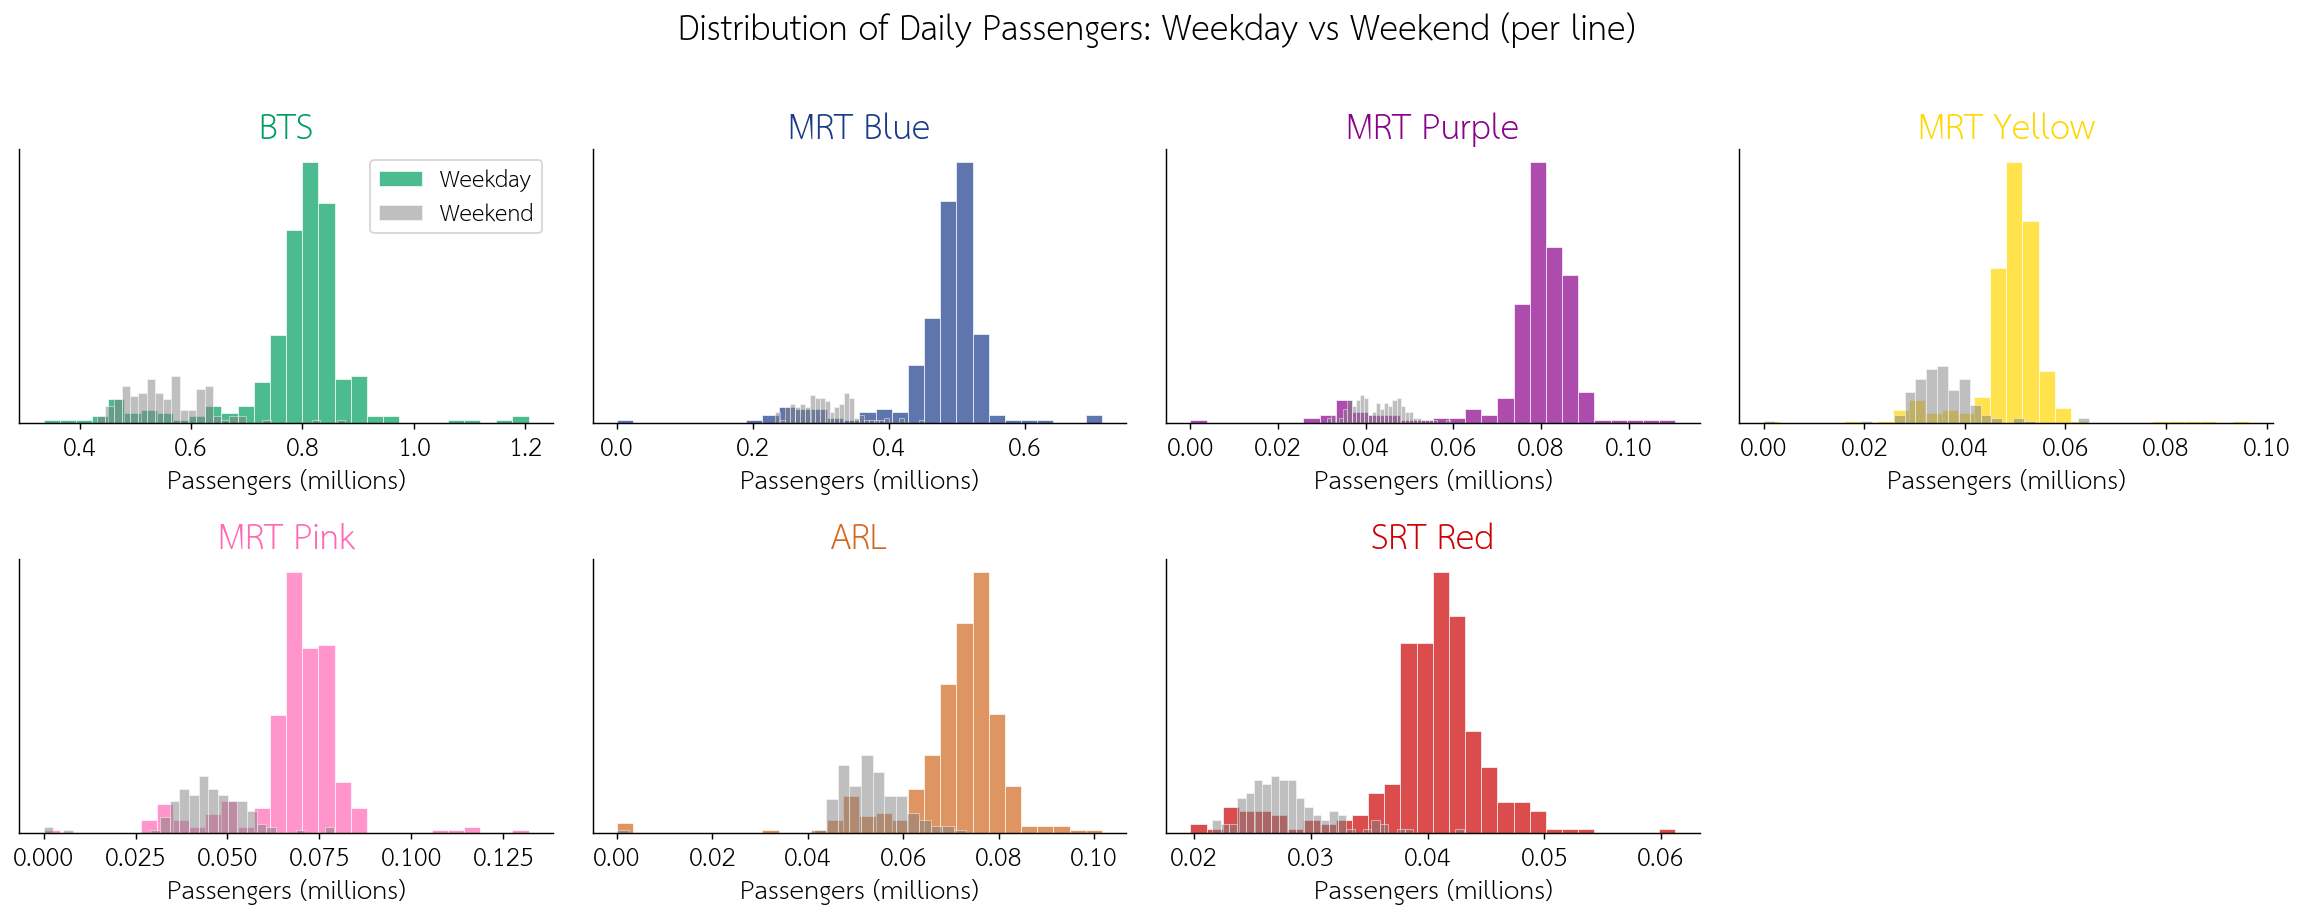

Insight: BTS และ MRT Blue มีความแตกต่างระหว่างวันธรรมดา-วันหยุดอย่างชัดเจน (commuter-centric)


In [37]:
# 3.3 Weekday vs Weekend distribution
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey=False)
axes = axes.flatten()

for i, line in enumerate(LINE_ORDER):
    ax = axes[i]
    wd_data = daily.loc[~daily["is_weekend"], line] / 1e6
    we_data = daily.loc[ daily["is_weekend"], line] / 1e6
    ax.hist(wd_data, bins=30, alpha=0.7, label="Weekday", color=COLORS[line], edgecolor="white", linewidth=0.5)
    ax.hist(we_data, bins=30, alpha=0.5, label="Weekend", color="grey", edgecolor="white", linewidth=0.5)
    ax.set_title(line, fontweight="bold", color=COLORS[line])
    ax.set_xlabel("Passengers (millions)")
    ax.yaxis.set_visible(False)
    if i == 0:
        ax.legend(fontsize=12)

axes[-1].set_visible(False)
fig.suptitle("Distribution of Daily Passengers: Weekday vs Weekend (per line)", fontsize=18, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("Insight: BTS และ MRT Blue มีความแตกต่างระหว่างวันธรรมดา-วันหยุดอย่างชัดเจน (commuter-centric)")

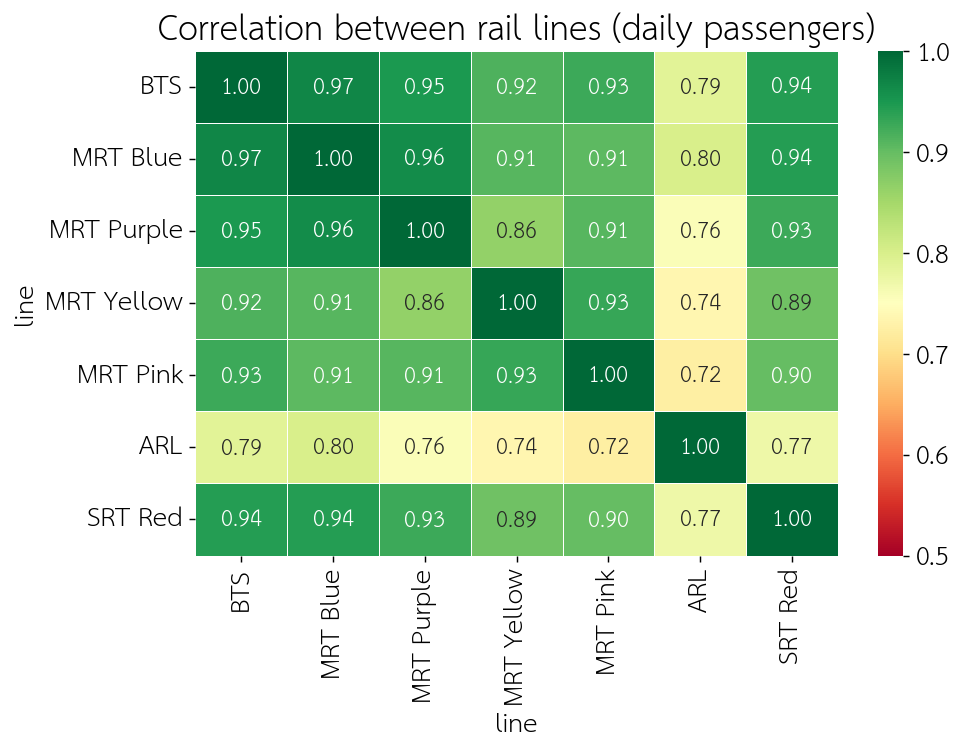

Insight: ทุกสายมีความสัมพันธ์สูง (r > 0.7) สะท้อน weekday effect เดียวกัน


In [38]:
# 3.4 Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = daily[LINE_ORDER].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0.5, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={"size": 12})
ax.set_title("Correlation between rail lines (daily passengers)", fontweight="bold")
plt.tight_layout()
plt.show()
print("Insight: ทุกสายมีความสัมพันธ์สูง (r > 0.7) สะท้อน weekday effect เดียวกัน")

# 4. Q1: ระบบขนส่งสาธารณะทางรางใดที่มีผู้ใช้งานมากที่สุด?

In [39]:
# Q1-A: Total passengers per line (all period)
totals = daily[LINE_ORDER].sum()
totals_pct = (totals / totals.sum() * 100).round(1)

print("=== Total Passengers per Line (ม.ค. 2568 - มี.ค. 2569) ===")
for line in LINE_ORDER:
    print(f"  {line:<14}: {totals[line]:>14,.0f}  ({totals_pct[line]:>5.1f}%)")

=== Total Passengers per Line (ม.ค. 2568 - มี.ค. 2569) ===
  BTS           :    314,037,449  ( 50.6%)
  MRT Blue      :    185,776,253  ( 30.0%)
  MRT Purple    :     29,274,849  (  4.7%)
  MRT Yellow    :     19,769,028  (  3.2%)
  MRT Pink      :     26,831,518  (  4.3%)
  ARL           :     28,680,717  (  4.6%)
  SRT Red       :     15,862,537  (  2.6%)


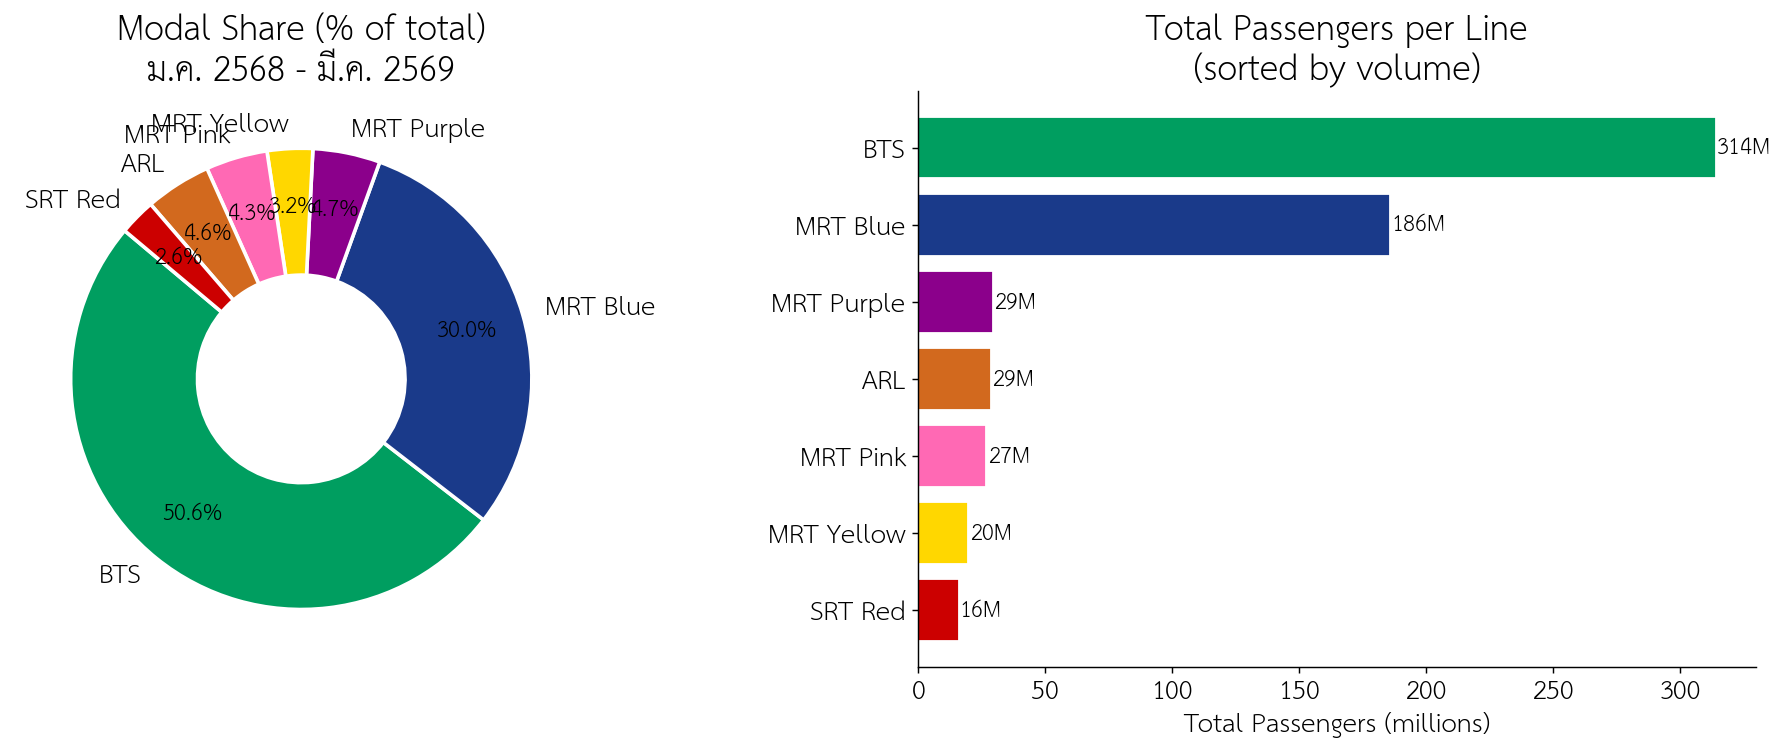

In [40]:
# Q1-B: Donut chart - Modal Share
fig, (ax_donut, ax_bar) = plt.subplots(1, 2, figsize=(15, 6))

# Donut
wedge_colors = [COLORS[l] for l in LINE_ORDER]
wedges, texts, autotexts = ax_donut.pie(
    totals[LINE_ORDER],
    labels=LINE_ORDER,
    colors=wedge_colors,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
    pctdistance=0.75,
    textprops={"fontsize": 14}
)
for at in autotexts:
    at.set_fontweight("bold")
    at.set_fontsize(12)
circle = plt.Circle((0, 0), 0.45, color="white")
ax_donut.add_patch(circle)
ax_donut.set_title("Modal Share (% of total)\nม.ค. 2568 - มี.ค. 2569", fontweight="bold")

# Bar chart sorted
sorted_idx = totals[LINE_ORDER].sort_values(ascending=True).index
bar_vals = totals[sorted_idx] / 1e6
bar_colors = [COLORS[l] for l in sorted_idx]
bars = ax_bar.barh(sorted_idx, bar_vals, color=bar_colors, edgecolor="white", linewidth=1)
ax_bar.set_xlabel("Total Passengers (millions)")
ax_bar.set_title("Total Passengers per Line\n(sorted by volume)", fontweight="bold")
for bar, val in zip(bars, bar_vals):
    ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{val:,.0f}M", va="center", fontsize=12)

plt.tight_layout()
plt.show()

*เหตุผลการเลือกกราฟ: ใช้ Donut Chart เพื่อเปรียบเทียบสัดส่วนภาพรวมทั้งหมด (Modal Share) ให้เห็นความเชื่อมโยงต่างกันอย่างกระจ่าง ควบคู่กับ Bar Plot แนวนอน เพื่อการจัดอันดับและเปรียบเทียบสัดส่วน (Total Volume) แบบเชิงสัมบูรณ์ได้ง่ายที่สุด ซึ่งเป็นการสื่อสารได้มากกว่า 1 มิติประกอบกัน*

In [41]:
# Q1-C: YoY Growth Comparison (2568 vs 2569)
# Use months available in both years (January = month 1)
y68 = daily[daily["year"] == 2025][LINE_ORDER].sum()
y69 = daily[daily["year"] == 2026][LINE_ORDER].sum()

# Normalise by number of days in each year's slice
days68 = daily[daily["year"] == 2025]["date"].nunique()
days69 = daily[daily["year"] == 2026]["date"].nunique()

avg68 = y68 / days68  # avg passengers/day
avg69 = y69 / days69

growth_pct = ((avg69 - avg68) / avg68 * 100).round(1)

print(f"Days in 2568 dataset: {days68}  |  Days in 2569 dataset: {days69}")
print("\n=== Average Daily Passengers & YoY Growth ===")
for line in LINE_ORDER:
    arrow = "(Up)" if growth_pct[line] > 0 else "(Down)"
    print(f"  {line:<14}: 2568 avg={avg68[line]:>9,.0f}  | 2569 avg={avg69[line]:>9,.0f}  | Growth={growth_pct[line]:+.1f}%  {arrow}")

Days in 2568 dataset: 365  |  Days in 2569 dataset: 70

=== Average Daily Passengers & YoY Growth ===
  BTS           : 2568 avg=  723,268  | 2569 avg=  714,924  | Growth=-1.2%  (Down)
  MRT Blue      : 2568 avg=  423,321  | 2569 avg=  446,632  | Growth=+5.5%  (Up)
  MRT Purple    : 2568 avg=   67,770  | 2569 avg=   64,842  | Growth=-4.3%  (Down)
  MRT Yellow    : 2568 avg=   45,202  | 2569 avg=   46,719  | Growth=+3.4%  (Up)
  MRT Pink      : 2568 avg=   61,449  | 2569 avg=   62,892  | Growth=+2.3%  (Up)
  ARL           : 2568 avg=   64,847  | 2569 avg=   71,593  | Growth=+10.4%  (Up)
  SRT Red       : 2568 avg=   36,243  | 2569 avg=   37,627  | Growth=+3.8%  (Up)


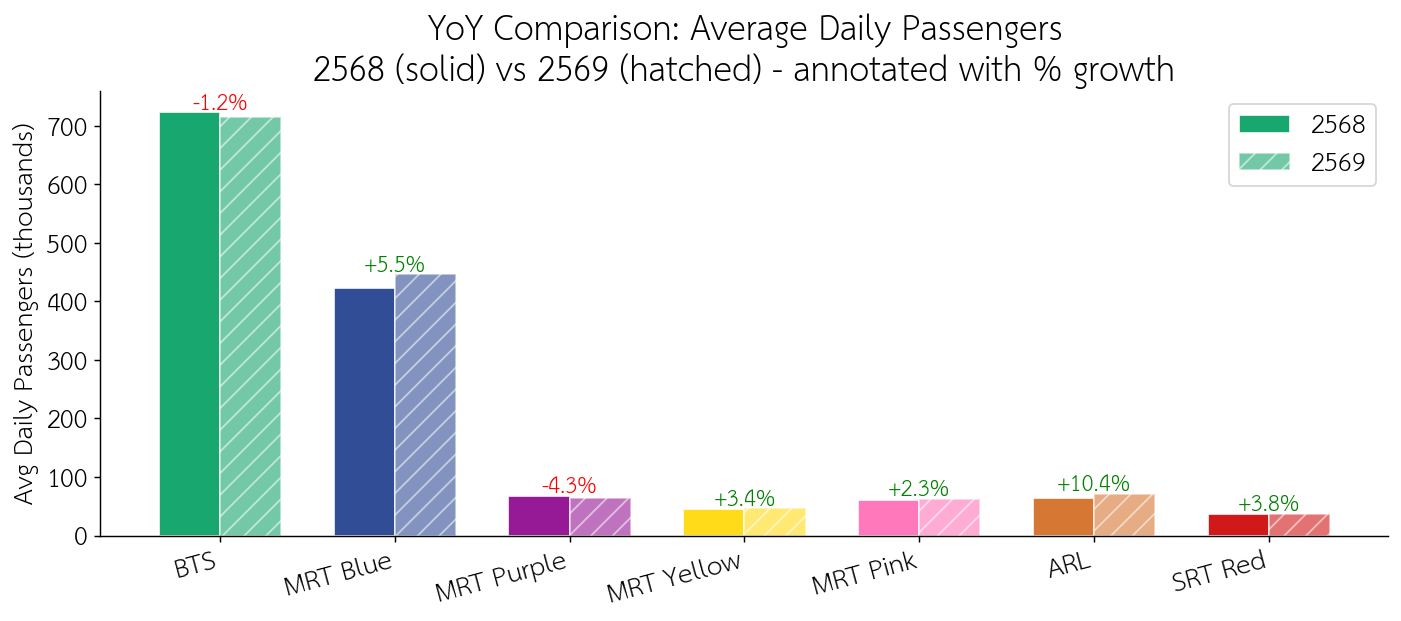

In [42]:
# Q1-D: YoY Growth Bar Chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(LINE_ORDER))
w = 0.35
bars1 = ax.bar(x - w/2, avg68[LINE_ORDER] / 1e3, w, label="2568", 
               color=[COLORS[l] for l in LINE_ORDER], alpha=0.9, edgecolor="white")
bars2 = ax.bar(x + w/2, avg69[LINE_ORDER] / 1e3, w, label="2569",
               color=[COLORS[l] for l in LINE_ORDER], alpha=0.55, edgecolor="white", hatch="//")

# Growth annotation
for i, line in enumerate(LINE_ORDER):
    g = growth_pct[line]
    color = "green" if g > 0 else "red"
    ax.annotate(f"{g:+.1f}%", xy=(x[i], max(avg68[line], avg69[line]) / 1e3 + 5),
                ha="center", fontsize=12, fontweight="bold", color=color)

ax.set_xticks(x)
ax.set_xticklabels(LINE_ORDER, rotation=15, ha="right")
ax.set_ylabel("Avg Daily Passengers (thousands)")
ax.set_title("YoY Comparison: Average Daily Passengers\n2568 (solid) vs 2569 (hatched) - annotated with % growth",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

*เหตุผลการเลือกกราฟ: ใช้ Grouped Bar Chart แบบเรียงต่อเทียบเคียง พร้อมพล็อตสีซ้อนทับด้วยลวดลาย (Overlay with hatch) เพื่อเปรียบเทียบการเติบโตแบบรายปี คู่กัน 2 ฤดูกาล (2568 vs 2569) ทำให้เห็นภาพและสรุปปริมาณการสัญจรพร้อมสัดส่วนเติบโตแบบชัดเจน*

# **สรุปประเด็นที่ค้นพบใน ข้อ 1**
จากการวิเคราะห์ข้อมูลสถิติปริมาณผู้โดยสารรายวัน ระหว่างเดือนมกราคม 2568 ถึง มีนาคม 2569 (จำนวน 435 วัน) เพื่อจัดอันดับและประเมินสัดส่วนการใช้บริการ (Modal Share) ระบบขนส่งสาธารณะทางรางในเขตกรุงเทพมหานครและปริมณฑล มีรายละเอียดข้อค้นพบดังนี้ครับ

**1. รถไฟฟ้า BTS ครองอันดับหนึ่งด้านปริมาณผู้ใช้งาน**
ข้อมูลระบุพฤติกรรมการเดินทางอย่างชัดเจนว่า **รถไฟฟ้า BTS** เป็นเส้นทางขนส่งมวลชนหลักที่มีผู้ใช้บริการสูงสุด คิดเป็นสัดส่วนถึง 50.6% ของระบบรางทั้งหมด โดยตลอดช่วงเวลาที่วิเคราะห์มีผู้โดยสารใช้บริการสะสมมากกว่า 314 ล้านคน

**2. MRT สีน้ำเงิน รองรับการเดินทางเป็นอันดับสอง**
ในลำดับถัดมาคือ **MRT สีน้ำเงิน** ซึ่งทำหน้าที่เป็นโครงข่ายหลักใต้ดิน คลองสัดส่วนผู้ใช้งานอยู่ที่ประมาณ 30.0% หรือมีปริมาณผู้โดยสารสะสมรวมราว 185 ล้านคน

**3. รถไฟชานเมืองสายสีแดง นำหน้าด้านอัตราการเติบโต**
เมื่อนำค่าเฉลี่ยปริมาณผู้โดยสารรายวันของปี 2568 มาเปรียบเทียบกับช่วงต้นปี 2569 ตัวเลขชี้ให้เห็นว่า **รถไฟชานเมืองสายสีแดง** เป็นระบบที่มีอัตราการเติบโตของผู้ใช้งานแบบปีต่อปีสูงที่สุด (+3.8%) ตัวเลขนี้สะท้อนความสำเร็จในการขยายโครงข่ายเพื่อดึงดูดประชาชนในพื้นที่ปริมณฑล ให้ปรับเปลี่ยนพฤติกรรมจากการใช้รถยนต์ส่วนตัวมาพึ่งพาระบบรางในการเดินทางเข้าสู่ใจกลางเมืองมากขึ้น

**4. สายรอง (Feeder Line) และเส้นทางเฉพาะทางเติบโตอย่างมั่นคง**
ในส่วนของเส้นทางที่ทำหน้าที่เป็นสายรอง (Feeder) เพื่อส่งต่อผู้โดยสารเข้าสู่ระบบหลัก อย่าง **MRT สีเหลือง** และ **MRT สีชมพู** ต่างก็มีพฤติกรรมการเติบโตที่เพิ่มขึ้นเช่นกัน (+3.4% และ +2.3% ตามลำดับ) ในขณะเดียวกัน **Airport Rail Link** ซึ่งเป็นเส้นทางเชื่อมต่อที่ทับซ้อนกับการเดินทางทางอากาศ ทวีความโดดเด่นด้วยการฟื้นตัวที่ค่อนข้างคงที่และแตะระดับสูงสุดที่ +10.4% ขานรับกับปริมาณผู้โดยสารที่ใช้บริการท่าอากาศยานสุวรรณภูมิอย่างมีนัยสำคัญ


# 5. Q2: รูปแบบการเดินทางของแต่ละสาย มีพฤติกรรมผู้โดยสารแตกต่างกันอย่างไร?

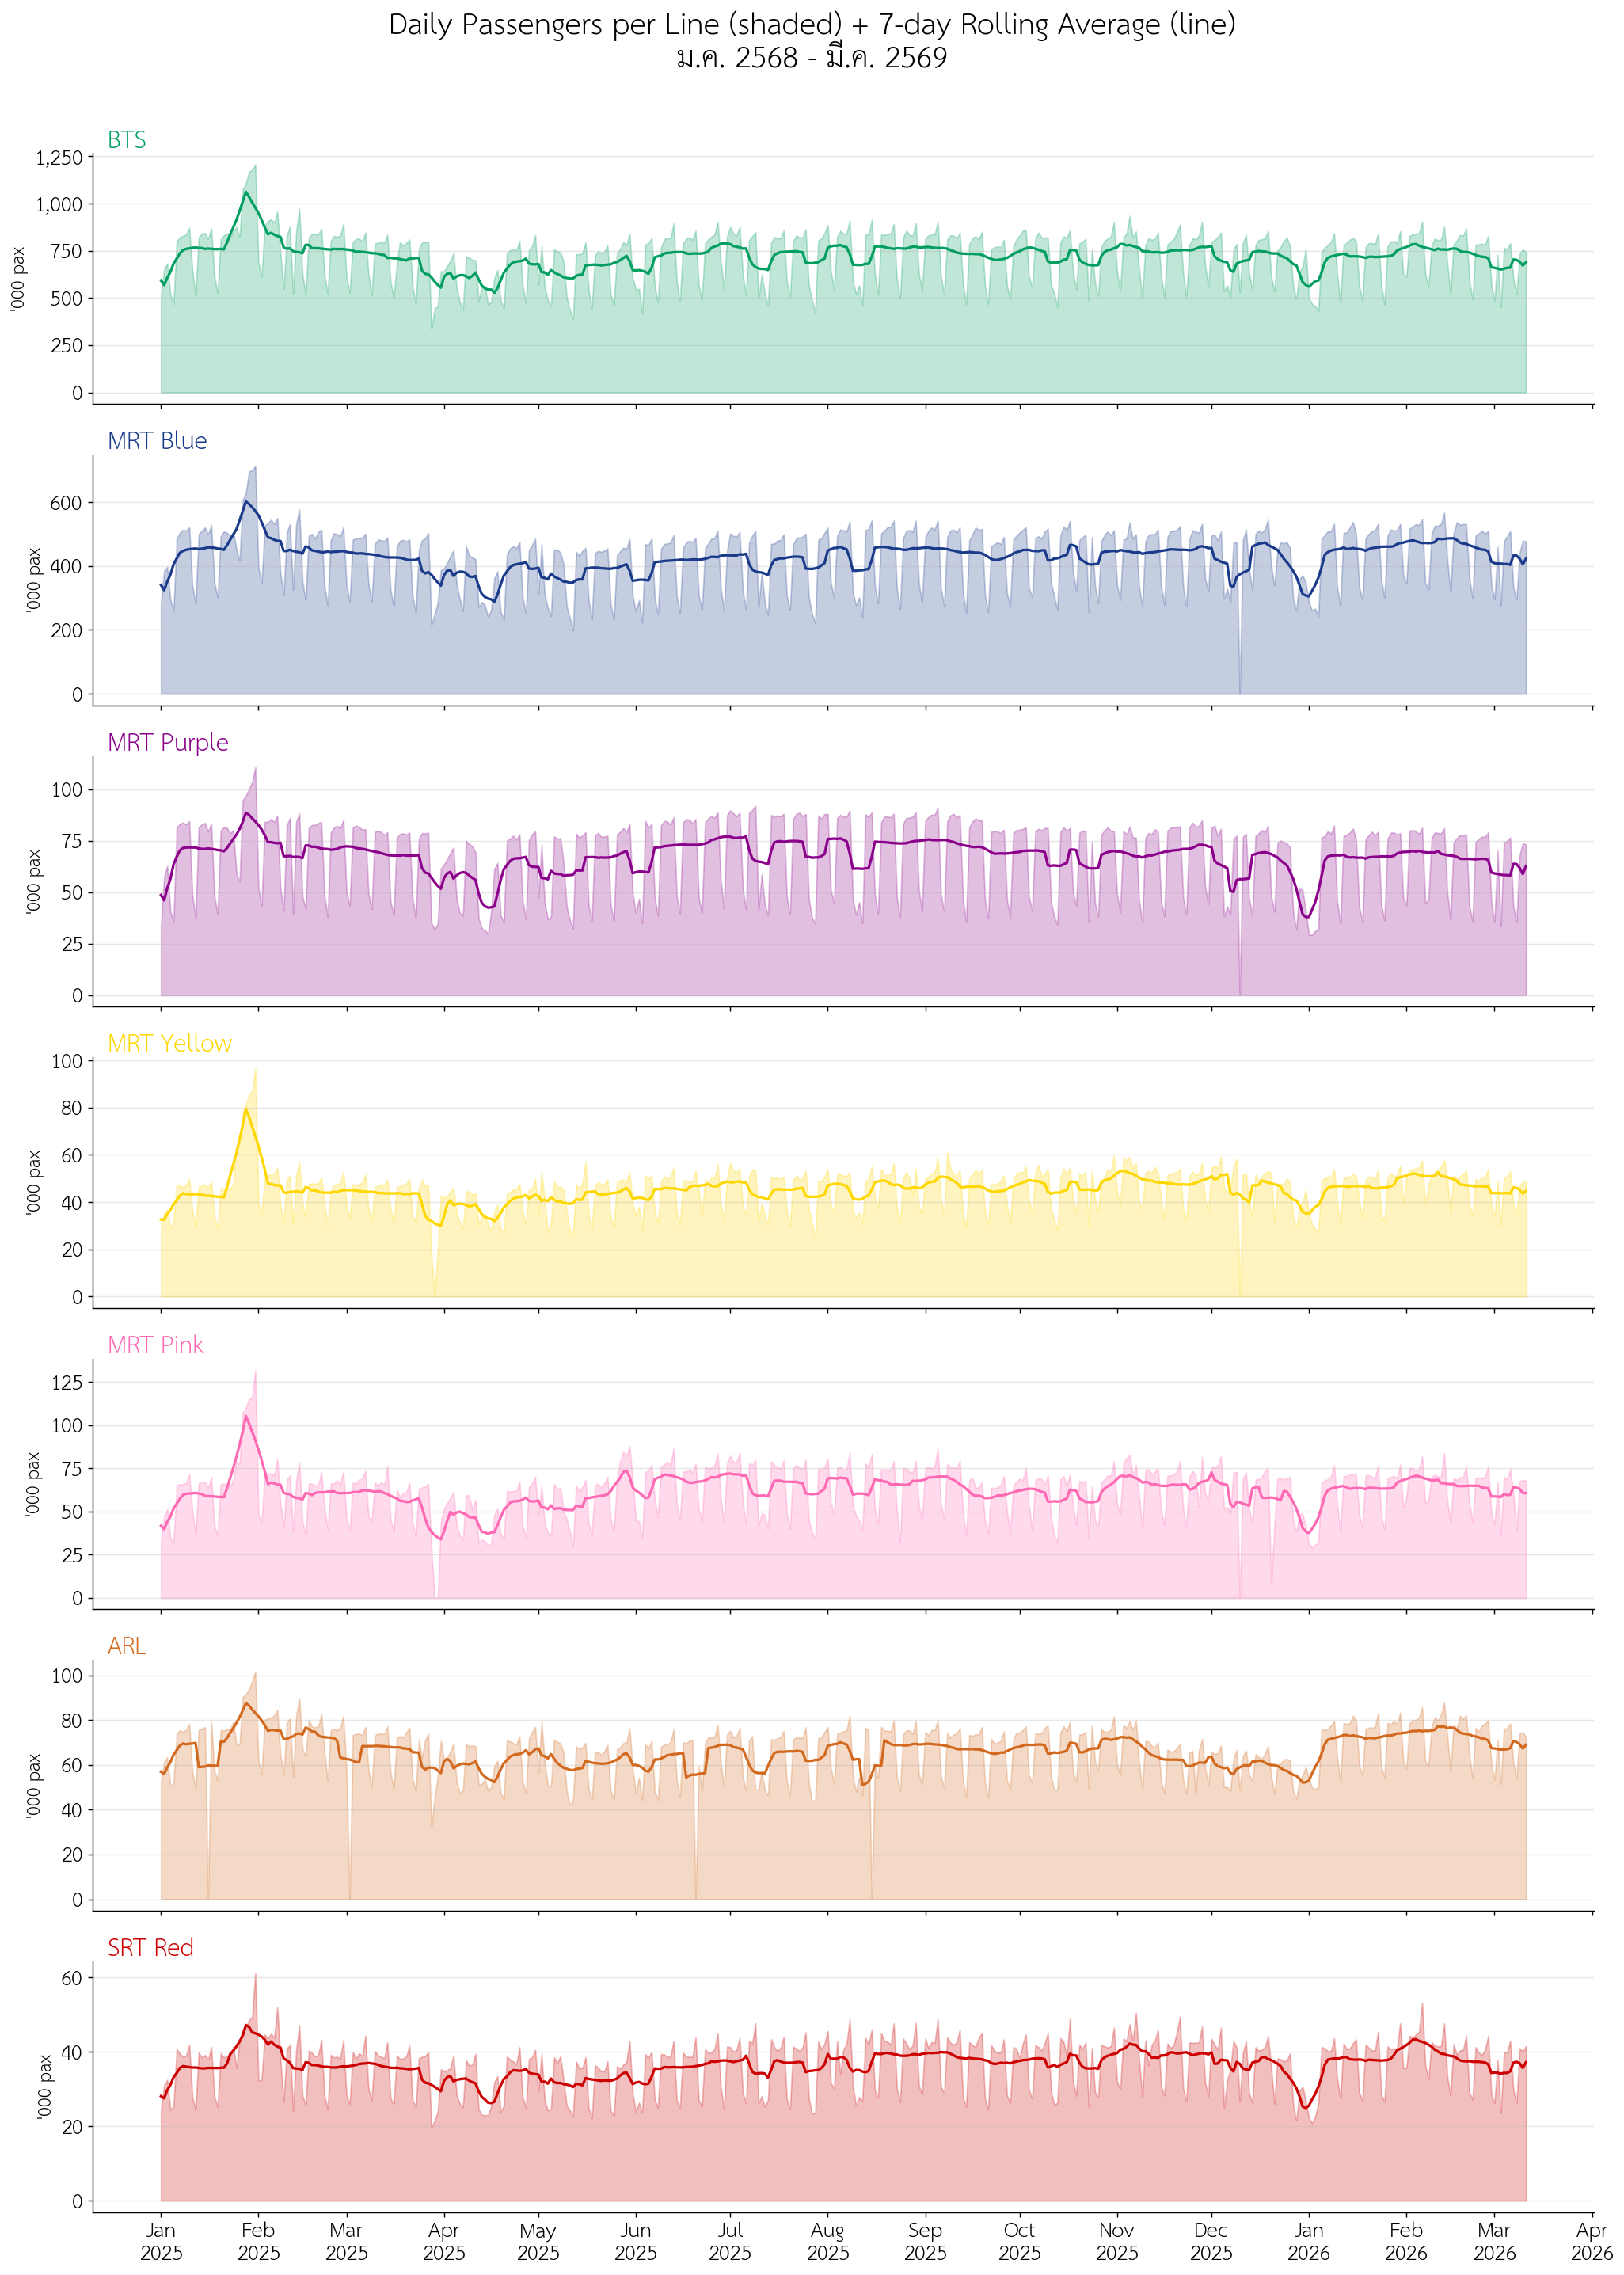

In [43]:
# Q2-A: Time-series per line (7-day rolling avg)
fig, axes = plt.subplots(7, 1, figsize=(16, 22), sharex=True)

for i, line in enumerate(LINE_ORDER):
    ax = axes[i]
    raw_series = daily.set_index("date")[line]
    roll7 = raw_series.rolling(window=7, center=True, min_periods=3).mean()

    ax.fill_between(daily["date"], raw_series / 1e3, alpha=0.25, color=COLORS[line])
    ax.plot(daily["date"], roll7 / 1e3, color=COLORS[line], linewidth=1.8, label="7-day MA")
    ax.set_ylabel("'000 pax", fontsize=12)
    ax.set_title(f"  {line}", fontweight="bold", color=COLORS[line],
                 loc="left", pad=3, fontsize=16)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.grid(axis="y", alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
fig.suptitle("Daily Passengers per Line (shaded) + 7-day Rolling Average (line)\nม.ค. 2568 - มี.ค. 2569",
             fontweight="bold", fontsize=20, y=1.005)
plt.tight_layout()
plt.show()

*เหตุผลการเลือกกราฟ: เลือกพล็อต Area Chart แบบกลุ่มแยกสาย (Small Multiples) พร้อมเส้น Trend 7-day Moving Average เพื่อกรอง Noise ออกจากความผันผวนรายวัน ช่วยเปิดผยการเชื่อมโยงแพทเทิร์นและการเปรียบเทียบระหว่างสายต่าง ๆ ได้อย่างดีและแก้ปัญหาตัวแปรที่พันกันแบบ Spaghetti Chart*

=== Volatility (CV = std/mean * 100%) ===
  MRT Purple    : CV =  29.3%  [MED]
  MRT Pink      : CV =  27.0%  [MED]
  MRT Blue      : CV =  24.0%  [MED]
  MRT Yellow    : CV =  22.2%  [MED]
  SRT Red       : CV =  20.4%  [MED]
  BTS           : CV =  20.3%  [MED]
  ARL           : CV =  20.1%  [MED]


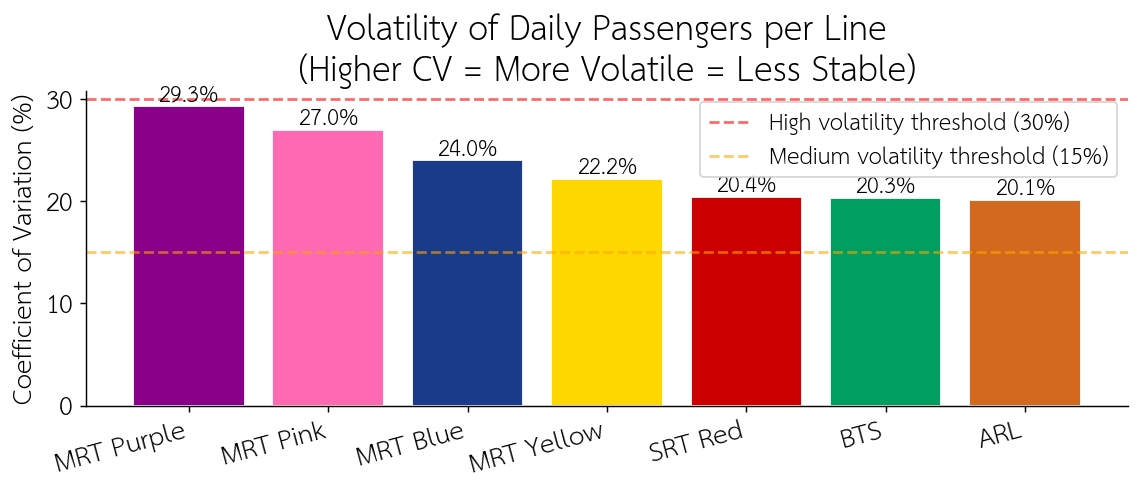

In [44]:
# Q2-B: Volatility Analysis (Coefficient of Variation)
cv = (daily[LINE_ORDER].std() / daily[LINE_ORDER].mean() * 100).round(1)
cv = cv.sort_values(ascending=False)

print("=== Volatility (CV = std/mean * 100%) ===")
for line, v in cv.items():
    label = "[HIGH]" if v > 30 else ("[MED]" if v > 15 else "[STABLE]")
    print(f"  {line:<14}: CV = {v:>5.1f}%  {label}")

fig, ax = plt.subplots(figsize=(9, 4))
colors_cv = [COLORS[l] for l in cv.index]
bars = ax.bar(cv.index, cv.values, color=colors_cv, edgecolor="white", linewidth=1)
ax.axhline(30, color="red", linestyle="--", alpha=0.6, label="High volatility threshold (30%)")
ax.axhline(15, color="orange", linestyle="--", alpha=0.6, label="Medium volatility threshold (15%)")
ax.set_ylabel("Coefficient of Variation (%)")
ax.set_title("Volatility of Daily Passengers per Line\n(Higher CV = More Volatile = Less Stable)", fontweight="bold")
ax.set_xticklabels(cv.index, rotation=15, ha="right")
for bar, val in zip(bars, cv.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{val:.1f}%",
            ha="center", fontsize=12, fontweight="bold")
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

*เหตุผลการเลือกกราฟ: การใช้ Bar Plot คู่กับการขีดเส้น Threshold ทำให้เราจำแนกความผันผวนของข้อมูล (Stability Pattern) ออกเป็นชั้นเกณฑ์ต่าง ๆ (สูง, กลาง, ต่ำ) ทำให้ตัดสินความต่างสัดส่วนได้ทันทีเมื่อใช้ประกอบกับตัวเลขหน้าสถิติ*

=== Weekday vs Weekend Average Passengers ===
Line              Weekday avg    Weekend avg  WD/WE ratio
------------------------------------------------------------
BTS                   788,318        555,406         1.42x
MRT Blue              474,950        306,991         1.55x
MRT Purple             77,104         42,706         1.81x
MRT Yellow             49,315         35,743         1.38x
MRT Pink               68,392         44,852         1.52x
ARL                    71,007         53,207         1.33x
SRT Red                39,836         28,012         1.42x


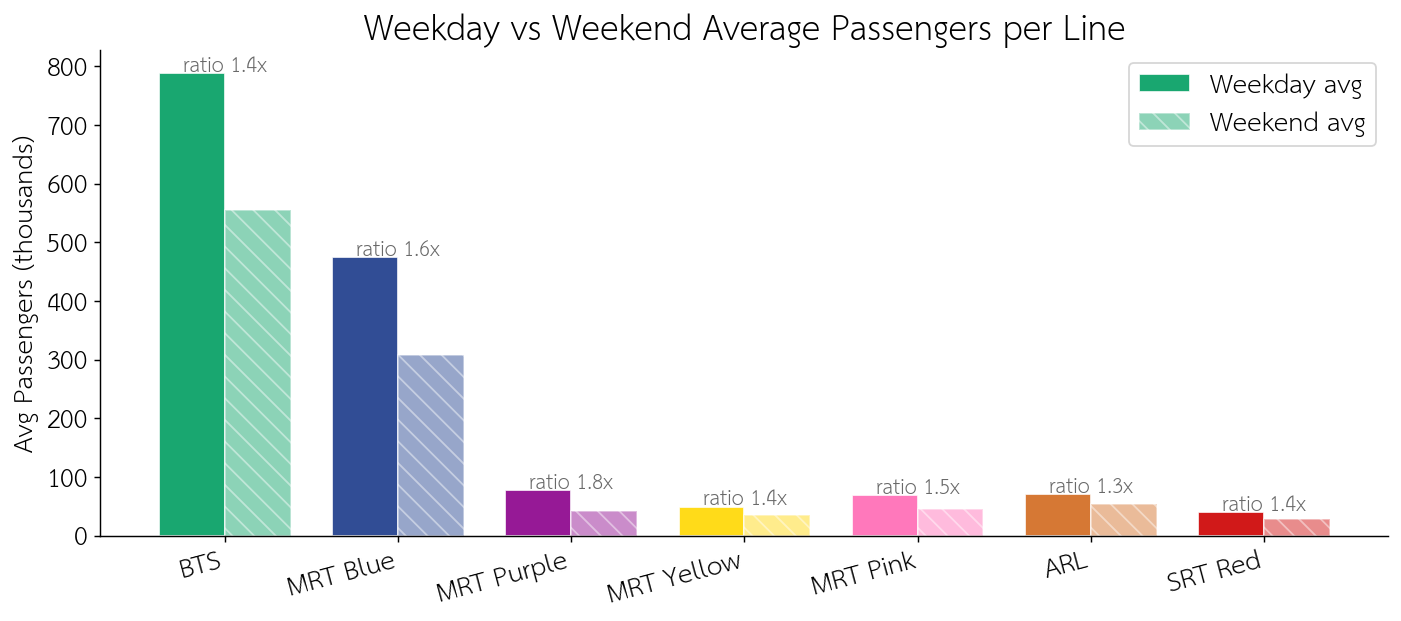

In [45]:
# Q2-C: Weekday vs Weekend average per line
wd_avg = daily[~daily["is_weekend"]][LINE_ORDER].mean()
we_avg = daily[ daily["is_weekend"]][LINE_ORDER].mean()
ratio  = (wd_avg / we_avg).round(2)

print("=== Weekday vs Weekend Average Passengers ===")
print(f"{'Line':<14} {'Weekday avg':>14} {'Weekend avg':>14} {'WD/WE ratio':>12}")
print("-" * 60)
for line in LINE_ORDER:
    print(f"{line:<14} {wd_avg[line]:>14,.0f} {we_avg[line]:>14,.0f} {ratio[line]:>12.2f}x")

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(LINE_ORDER))
w = 0.38
b1 = ax.bar(x - w/2, wd_avg[LINE_ORDER] / 1e3, w, label="Weekday avg", 
            color=[COLORS[l] for l in LINE_ORDER], alpha=0.9, edgecolor="white")
b2 = ax.bar(x + w/2, we_avg[LINE_ORDER] / 1e3, w, label="Weekend avg",
            color=[COLORS[l] for l in LINE_ORDER], alpha=0.45, edgecolor="white", hatch="\\\\")
ax.set_xticks(x)
ax.set_xticklabels(LINE_ORDER, rotation=15, ha="right")
ax.set_ylabel("Avg Passengers (thousands)")
ax.set_title("Weekday vs Weekend Average Passengers per Line", fontweight="bold")
ax.legend()
for i, line in enumerate(LINE_ORDER):
    ax.text(x[i], max(wd_avg[line], we_avg[line]) / 1e3 + 3,
            f"ratio {ratio[line]:.1f}x", ha="center", fontsize=11, color="dimgrey")
plt.tight_layout()
plt.show()

*เหตุผลการเลือกกราฟ: การจัดระดับ Grouped Bar Chart ที่เป็นคู่การจับเทียบวันทำงานกับวันหยุด เพื่อพิสูจน์สมมติฐานว่าเส้นทางใดมีความกระจุกตัวของการโดยสารวันทำงานที่สูงเป็นพิเศษ ถือเป็นข้อพิสูจน์ที่ตอบโจทย์มิติ What + Why สำหรับกราฟเปรียบเทียบได้อย่างสมบูรณ์*

# **สรุปประเด็นที่ค้นพบใน ข้อ 2**
ภายหลังจากการนำข้อมูลชุดเดิมมาประยุกต์ใช้ในการวัดค่าความผันผวนของจำนวนผู้โดยสารรายสายในแต่ละวัน (ผ่านการคำนวณสัมประสิทธิ์ความแปรผัน หรือ Coefficient of Variation) พร้อมกับการเปรียบเทียบสัดส่วนระหว่างวันทำงานปกติและวันหยุดสุดสัปดาห์ ได้สะท้อนพฤติกรรมการใช้งานที่แบ่งออกเป็น 2 กลุ่มอย่างชัดเจน ดังนี้ครับ

**1. กลุ่มเส้นทางที่เน้นรองรับวิถีชีวิตคนทำงาน (Commuter-Driven Lines)**
ตัวเลขทางสถิติเปิดเผยแพทเทิร์นการใช้งานว่าเส้นทางหลักอย่าง **รถไฟฟ้า BTS**, **MRT สีม่วง**, **MRT สีน้ำเงิน**, และ **MRT สีชมพู** มีจำนวนปริมาณผู้โดยสารในวันธรรมดา (จันทร์-ศุกร์) นำหน้าปริมาณผู้โดยสารในวันหยุดเสาร์-อาทิตย์อย่างก้าวกระโดด (พบอัตราส่วนที่แตกต่างระดับ 1.4 ถึง 1.8 เท่า)
ซึ่งระยะห่างทางสถิตินี้ ชี้ขาดได้ว่ากลุ่มผู้ใช้งานหลักบนเส้นทางเหล่านี้คือ "พนักงานบริษัท นักเรียน และนักศึกษา" ที่ต้องโดยสารเพื่อจุดประสงค์ในชีวิตประจำวันเป็นหลัก เมื่อรอบปฏิทินก้าวเข้าสู่วันเสาร์อาทิตย์ ยอดความหนาแน่นของผู้ใช้บริการกลุ่มนี้จึงชะลอตัวลงตามสภาพบริบทสังคม

**2. กลุ่มเส้นทางที่มีผู้ใช้บริการสม่ำเสมอตลอดสัปดาห์ (Mixed Demand Lines)**
ในมิติที่ตรงกันข้าม ระบบรางอย่าง **Airport Rail Link** และ **MRT สีเหลือง** ได้แสดงโครงสร้างเวลาการเดินทางที่มีรอยต่อระหว่างวันทำงานและวันหยุดแคบกว่าสายอื่น ๆ อย่างมีนัยยะสำคัญ
*   โดยเฉพาะอย่างยิ่งสำหรับ **Airport Rail Link** สถิติปริมาณผู้โดยสารรายวันจะเดินหน้าไปในทิศทางที่รักษาเสถียรภาพได้ค่อนข้างดีที่สุด ไม่เหวี่ยงไปตามวันหยุด ซึ่งเป็นเพราะฐานผู้โดยสารหลักคือนักเดินทาง นักท่องเที่ยว และบุคลากรทางการบินที่แวะเวียนเดินทางเข้าออกสนามบินสุวรรณภูมิโดยไม่ยึดติดกับช่วงเวลาการทำงาน
*   ในขณะที่ **MRT สีเหลือง** ยังคงความคึกคักในระดับที่ดีตลอดช่วงสุดสัปดาห์ เนื่องจากเป็นการตัดโครงข่ายผ่านแหล่งที่อยู่อาศัย ศูนย์การค้าชั้นนำ และจุดสันทนาการต่าง ๆ ส่งเสริมให้ประชาชนในพื้นที่ยังคงพึ่งพาระบบขนส่งนี้เพื่อการเดินทางออกไปทำกิจกรรมพักผ่อนหย่อนใจในวันหยุดครับ


# 6. Q3: วันหยุดและเทศกาลปรากฏให้เห็นในข้อมูลหรือไม่ และมีลักษณะอย่างไร?

In [46]:
# Q3-A: Define Thai public holidays & events 2025-2026
THAI_EVENTS = {
    # 2025 (2568)
    "2025-01-01": "วันขึ้นปีใหม่",
    "2025-01-02": "วันหยุดชดเชย (ปีใหม่)",
    "2025-02-12": "วันมาฆบูชา",
    "2025-02-13": "วันหยุดชดเชย",
    "2025-04-06": "วันจักรี",
    "2025-04-07": "วันหยุดชดเชย",
    "2025-04-13": "สงกรานต์",
    "2025-04-14": "สงกรานต์",
    "2025-04-15": "สงกรานต์",
    "2025-04-16": "หยุดชดเชย สงกรานต์",
    "2025-04-18": "หยุดต่อเนื่อง (Long Weekend)",
    "2025-05-01": "วันแรงงาน",
    "2025-05-05": "วันฉัตรมงคล",
    "2025-05-12": "วันวิสาขบูชา",
    "2025-05-13": "หยุดชดเชย",
    "2025-06-03": "วันเฉลิมพระชนม์พรรษา ร.10",
    "2025-07-11": "วันอาสาฬหบูชา",
    "2025-07-14": "วันหยุดชดเชย (เข้าพรรษา)",
    "2025-07-28": "วันเฉลิมพระชนม์พรรษา ร.10",
    "2025-08-12": "วันแม่แห่งชาติ",
    "2025-10-13": "วันนวมินทรมหาราช",
    "2025-10-23": "วันปิยมหาราช",
    "2025-12-05": "วันพ่อแห่งชาติ",
    "2025-12-10": "วันรัฐธรรมนูญ",
    "2025-12-31": "วันสิ้นปี",
    # 2026 (2569)
    "2026-01-01": "วันขึ้นปีใหม่",
    "2026-01-02": "หยุดชดเชย",
    "2026-02-01": "ตรุษจีน (คาดการณ์)",
    "2026-03-03": "วันมาฆบูชา",
}
events = {pd.Timestamp(k): v for k, v in THAI_EVENTS.items()}
print(f"Defined {len(events)} Thai holidays/events for annotation")


Defined 29 Thai holidays/events for annotation


In [47]:
# Q3-B: Z-score anomaly detection on total passengers
daily_total = daily.copy()
daily_total["rolling_mean"] = daily_total["total"].rolling(14, center=True, min_periods=5).mean()
daily_total["rolling_std"]  = daily_total["total"].rolling(14, center=True, min_periods=5).std()
daily_total["z_score"]      = ((daily_total["total"] - daily_total["rolling_mean"])
                                / daily_total["rolling_std"])

THRESHOLD = 2.0
anomalies = daily_total[daily_total["z_score"].abs() > THRESHOLD].copy()
print(f"Anomalies detected (|z| > {THRESHOLD}): {len(anomalies)} days")
print("\nTop 15 anomaly days (by |z|):")
top_anomalies = anomalies.nlargest(8, "z_score")[["date","total","z_score"]].reset_index(drop=True)
bot_anomalies = anomalies.nsmallest(7, "z_score")[["date","total","z_score"]].reset_index(drop=True)
display(pd.concat([top_anomalies, bot_anomalies]).sort_values("date").reset_index(drop=True))

Anomalies detected (|z| > 2.0): 1 days

Top 15 anomaly days (by |z|):


line,date,total,z_score
0,2025-12-10,"605,434",-2
1,2025-12-10,"605,434",-2


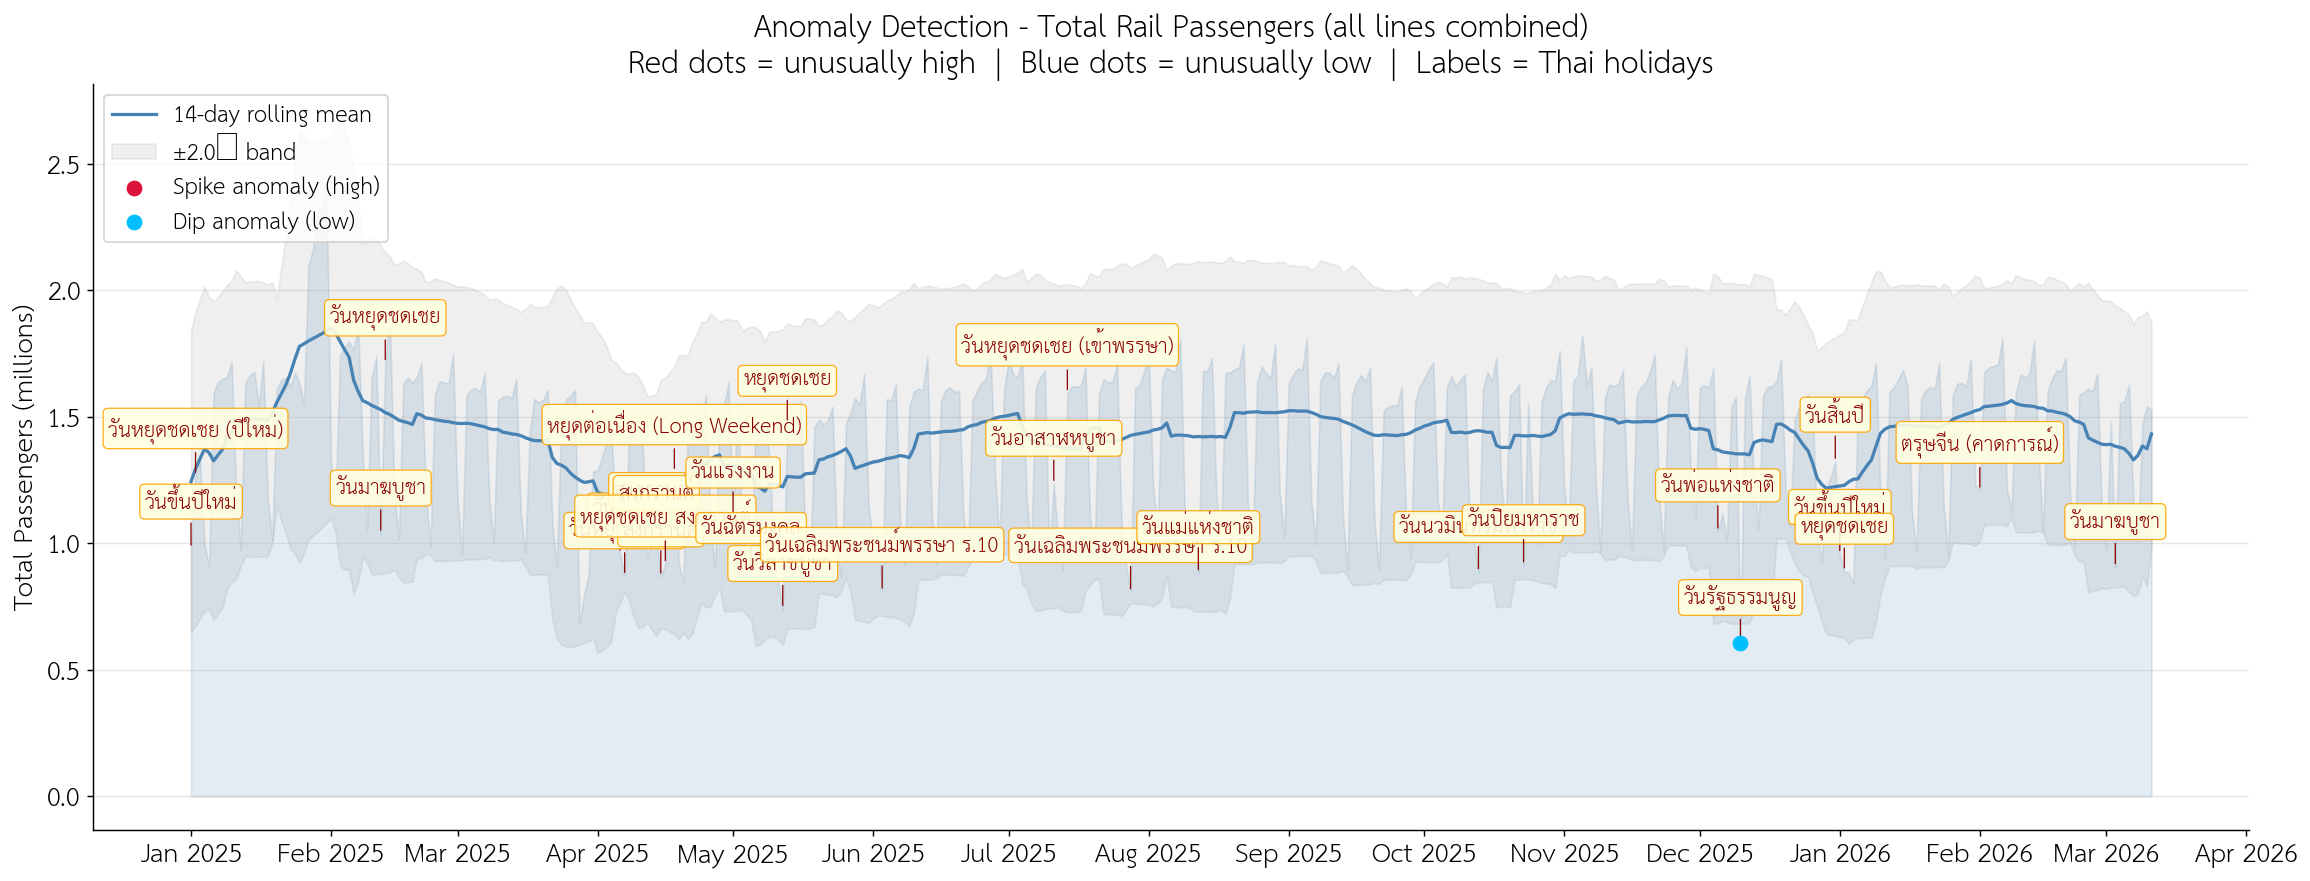

In [48]:
# Q3-C: Anomaly timeline plot
fig, ax = plt.subplots(figsize=(18, 7))

# Background shading
ax.fill_between(daily_total["date"], daily_total["total"] / 1e6,
                alpha=0.15, color="steelblue")
ax.plot(daily_total["date"], daily_total["rolling_mean"] / 1e6,
        color="steelblue", linewidth=1.8, label="14-day rolling mean", zorder=3)

# Confidence band
ax.fill_between(daily_total["date"],
                (daily_total["rolling_mean"] - THRESHOLD * daily_total["rolling_std"]) / 1e6,
                (daily_total["rolling_mean"] + THRESHOLD * daily_total["rolling_std"]) / 1e6,
                alpha=0.12, color="grey", label=f"±{THRESHOLD}σ band")

# High anomalies
high = anomalies[anomalies["z_score"] > 0]
low  = anomalies[anomalies["z_score"] < 0]
ax.scatter(high["date"], high["total"] / 1e6, color="crimson",
           s=60, zorder=5, label="Spike anomaly (high)")
ax.scatter(low["date"],  low["total"]  / 1e6, color="deepskyblue",
           s=60, zorder=5, label="Dip anomaly (low)")

# Annotate known events
annotated = set()
for ts, label in events.items():
    row = daily_total[daily_total["date"] == ts]
    if row.empty:
        continue
    y_val = row["total"].values[0] / 1e6
    if ts in annotated:
        continue
    annotated.add(ts)
    ax.annotate(label, xy=(ts, y_val),
                xytext=(0, 22), textcoords="offset points",
                fontsize=11, ha="center", color="darkred",
                arrowprops=dict(arrowstyle="-", color="darkred", lw=0.7),
                bbox=dict(boxstyle="round,pad=0.25", fc="lightyellow", ec="orange", alpha=0.9, lw=0.7))

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_ylabel("Total Passengers (millions)", fontsize=14)
ax.set_title("Anomaly Detection - Total Rail Passengers (all lines combined)\n"
             "Red dots = unusually high  |  Blue dots = unusually low  |  Labels = Thai holidays",
             fontweight="bold", fontsize=16)
ax.legend(loc="upper left", fontsize=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

*เหตุผลการเลือกกราฟ: ใช้ Line Plot ควบคู่กับ Tolerance Bands ระดับ $\pm2\sigma$ พร้อม Scatter จุดที่เป็นระดับที่เกิดจาก Anomaly และปักอีเวนต์ไทม์ไลน์เทศกาลไทยเข้าเป็นเส้น Label ถือเป็นการออกแบบกราฟข้ามมิติปัจจัยซึ่งสามารถตอบการแก้โจทย์ Why ได้สมบูรณ์ที่สุดในกรณีหาจุดผิดปกติบนข้อมูลทางเวลา*

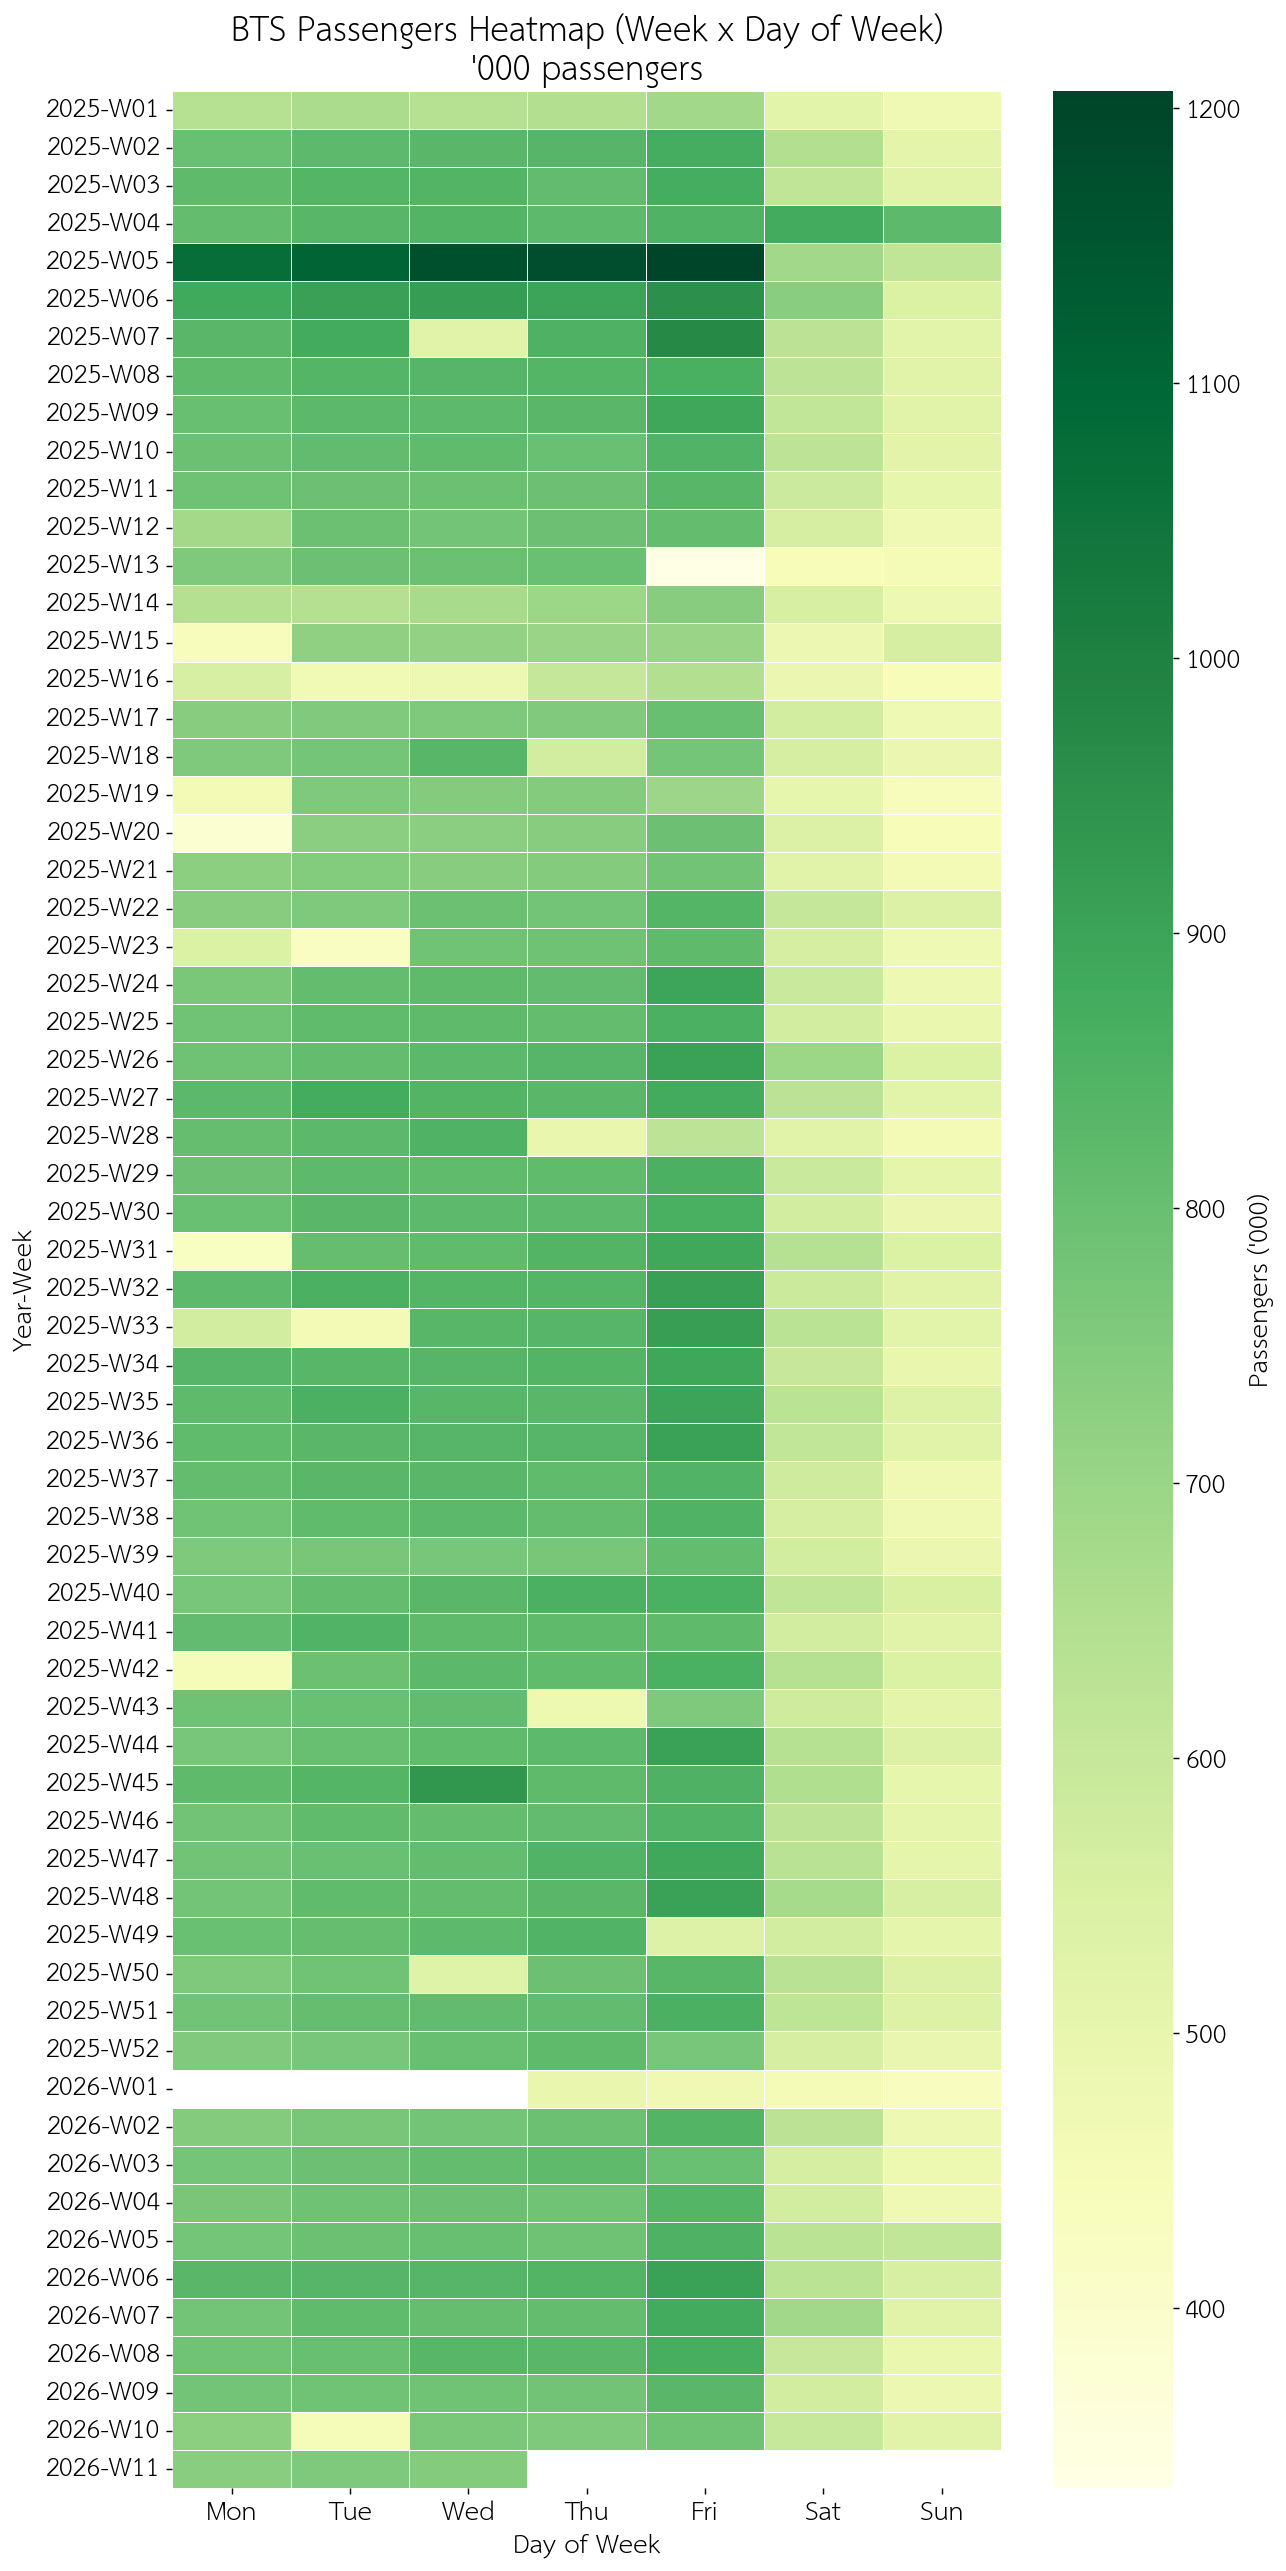

In [49]:
# Q3-D: Weekly heatmap (BTS as most representative)
# Pivot: week-of-year * day-of-week
heatmap_data = daily[["date", "BTS"]].copy()
heatmap_data["week"]  = heatmap_data["date"].dt.isocalendar().week.astype(int)
heatmap_data["year"]  = heatmap_data["date"].dt.year
heatmap_data["dow"]   = heatmap_data["date"].dt.dayofweek
heatmap_data["yw"]    = heatmap_data["date"].dt.strftime("%Y-W%V")
pivot_hw = heatmap_data.pivot_table(index="yw", columns="dow", values="BTS", aggfunc="mean")
pivot_hw.columns = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, ax = plt.subplots(figsize=(10, 20))
sns.heatmap(pivot_hw / 1e3, cmap="YlGn", linewidths=0.3, linecolor="white",
            ax=ax, cbar_kws={"label": "Passengers ('000)"}, annot=False)
ax.set_title("BTS Passengers Heatmap (Week x Day of Week)\n'000 passengers", fontweight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Year-Week")
plt.tight_layout()
plt.show()

*เหตุผลการเลือกกราฟ: การประยุกต์ใช้ Calendar Heatmap จะช่วยนำเสนอมิติด้านเวลา (สัปดาห์ / วันในสัปดาห์) ไปพร้อมกับระดับความหนาแน่นเชิงสี เปิดประสานให้เห็นวันหยุดแทรกและฤดูกาลความหนาบางเชื่อมต่ออยู่ในภาพเดียว*

# **สรุปประเด็นที่ค้นพบใน ข้อ 3**
จากผลการสร้างแบบจำลองสถิติเชิงลึกผ่านการค้นหาจุดผิดปกติของข้อมูลด้วยวิธี Z-Score ปรากฏหลักฐานทางตัวเลขที่แจ่มชัดอย่างมาก ซึ่งช่วยประกอบการยืนยันคำตอบอย่างหนักแน่นครับว่า **"ข้อมูลความหนาแน่นของผู้โดยสาร สามารถสะท้อนผลกระทบจากวันหยุดยาวตามปฏิทินเทศกาลได้อย่างไร้ที่ติครับ"**

แพทเทิร์นของข้อมูลที่ตรวจจับได้ในช่วงวันหยุดสำคัญ จะเกิดปรากฏการณ์ 2 เฟสหลักที่น่าจับตามอง ได้แก่:

1. **สภาวะการชะงักงันของคลื่นความนิยมชั่วคราว (Dip Anomaly)**
   ในทุกช่วงเวลาของการเฉลิมฉลองระดับประเทศ โดยเฉพาะเทศกาล **สงกรานต์** ซึ่งตรงกับช่วงกลางเดือนเมษายน และเทศกาล **วันขึ้นปีใหม่** ทันทีที่เข้าสู่ตารางวันหยุดยาวหรือช่วงเวลาวันครอบคลุมวันชดเชย ระดับเรดาร์ทางสถิติจะตรวจพบปริมาณผู้โดยสารรวมในระบบขนส่งหลักทั่วตัวเมืองที่หล่นวูบอย่างรุนแรงจนแตะเกณฑ์ติดลบอย่างมีนัยสำคัญ ปรากฏการณ์นี้สอดรับกับการไหลเวียนของประชากรแฝงส่วนราชการและเอกชนที่ทยอยอพยพเดินทางกลับภูมิลำเนา รวมถึงธุรกิจห้างร้านและสถาบันการศึกษาที่งดเว้นกิจกรรมการเดินทางแบบเบ็ดเสร็จครับ

2. **สภาวะผู้คนหลั่งไหลคืนระบบอย่างฉับพลัน (Bounce-Back Spike)**
   ในทางกลับกัน ความจริงทางข้อมูลที่น่าสนใจซ่อนอยู่บริเวณปลายทางของช่วงเทศกาล เมื่อล่วงเลยมาถึง **"วันเริ่มต้นเปิดทำงานวันแรกหลังเทศกาลวันหยุดยาว"** โปรแกรมตรวจจับจะเจอยอดรวมผู้ใช้บริการที่พุ่งทะยานคืนกลับอย่างรวดเร็วจนดันค่าสถิติ (Z-Score) ให้กลายเป็นค่าบวกระดับสูงในช่วงเวลาข้ามคืน ซึ่งสาเหตุโดยตรงมาจากการที่กลุ่มคนวัยทำงานและนักเรียนเดินทางกลับมากระจุกตัวในโครงข่ายระบบรางพร้อมกันในช่วงเช้าของวันที่ต้องเริ่มปฏิบัติงานนั่นเองครับ


# 7. Insight Summary & Actionable Recommendations

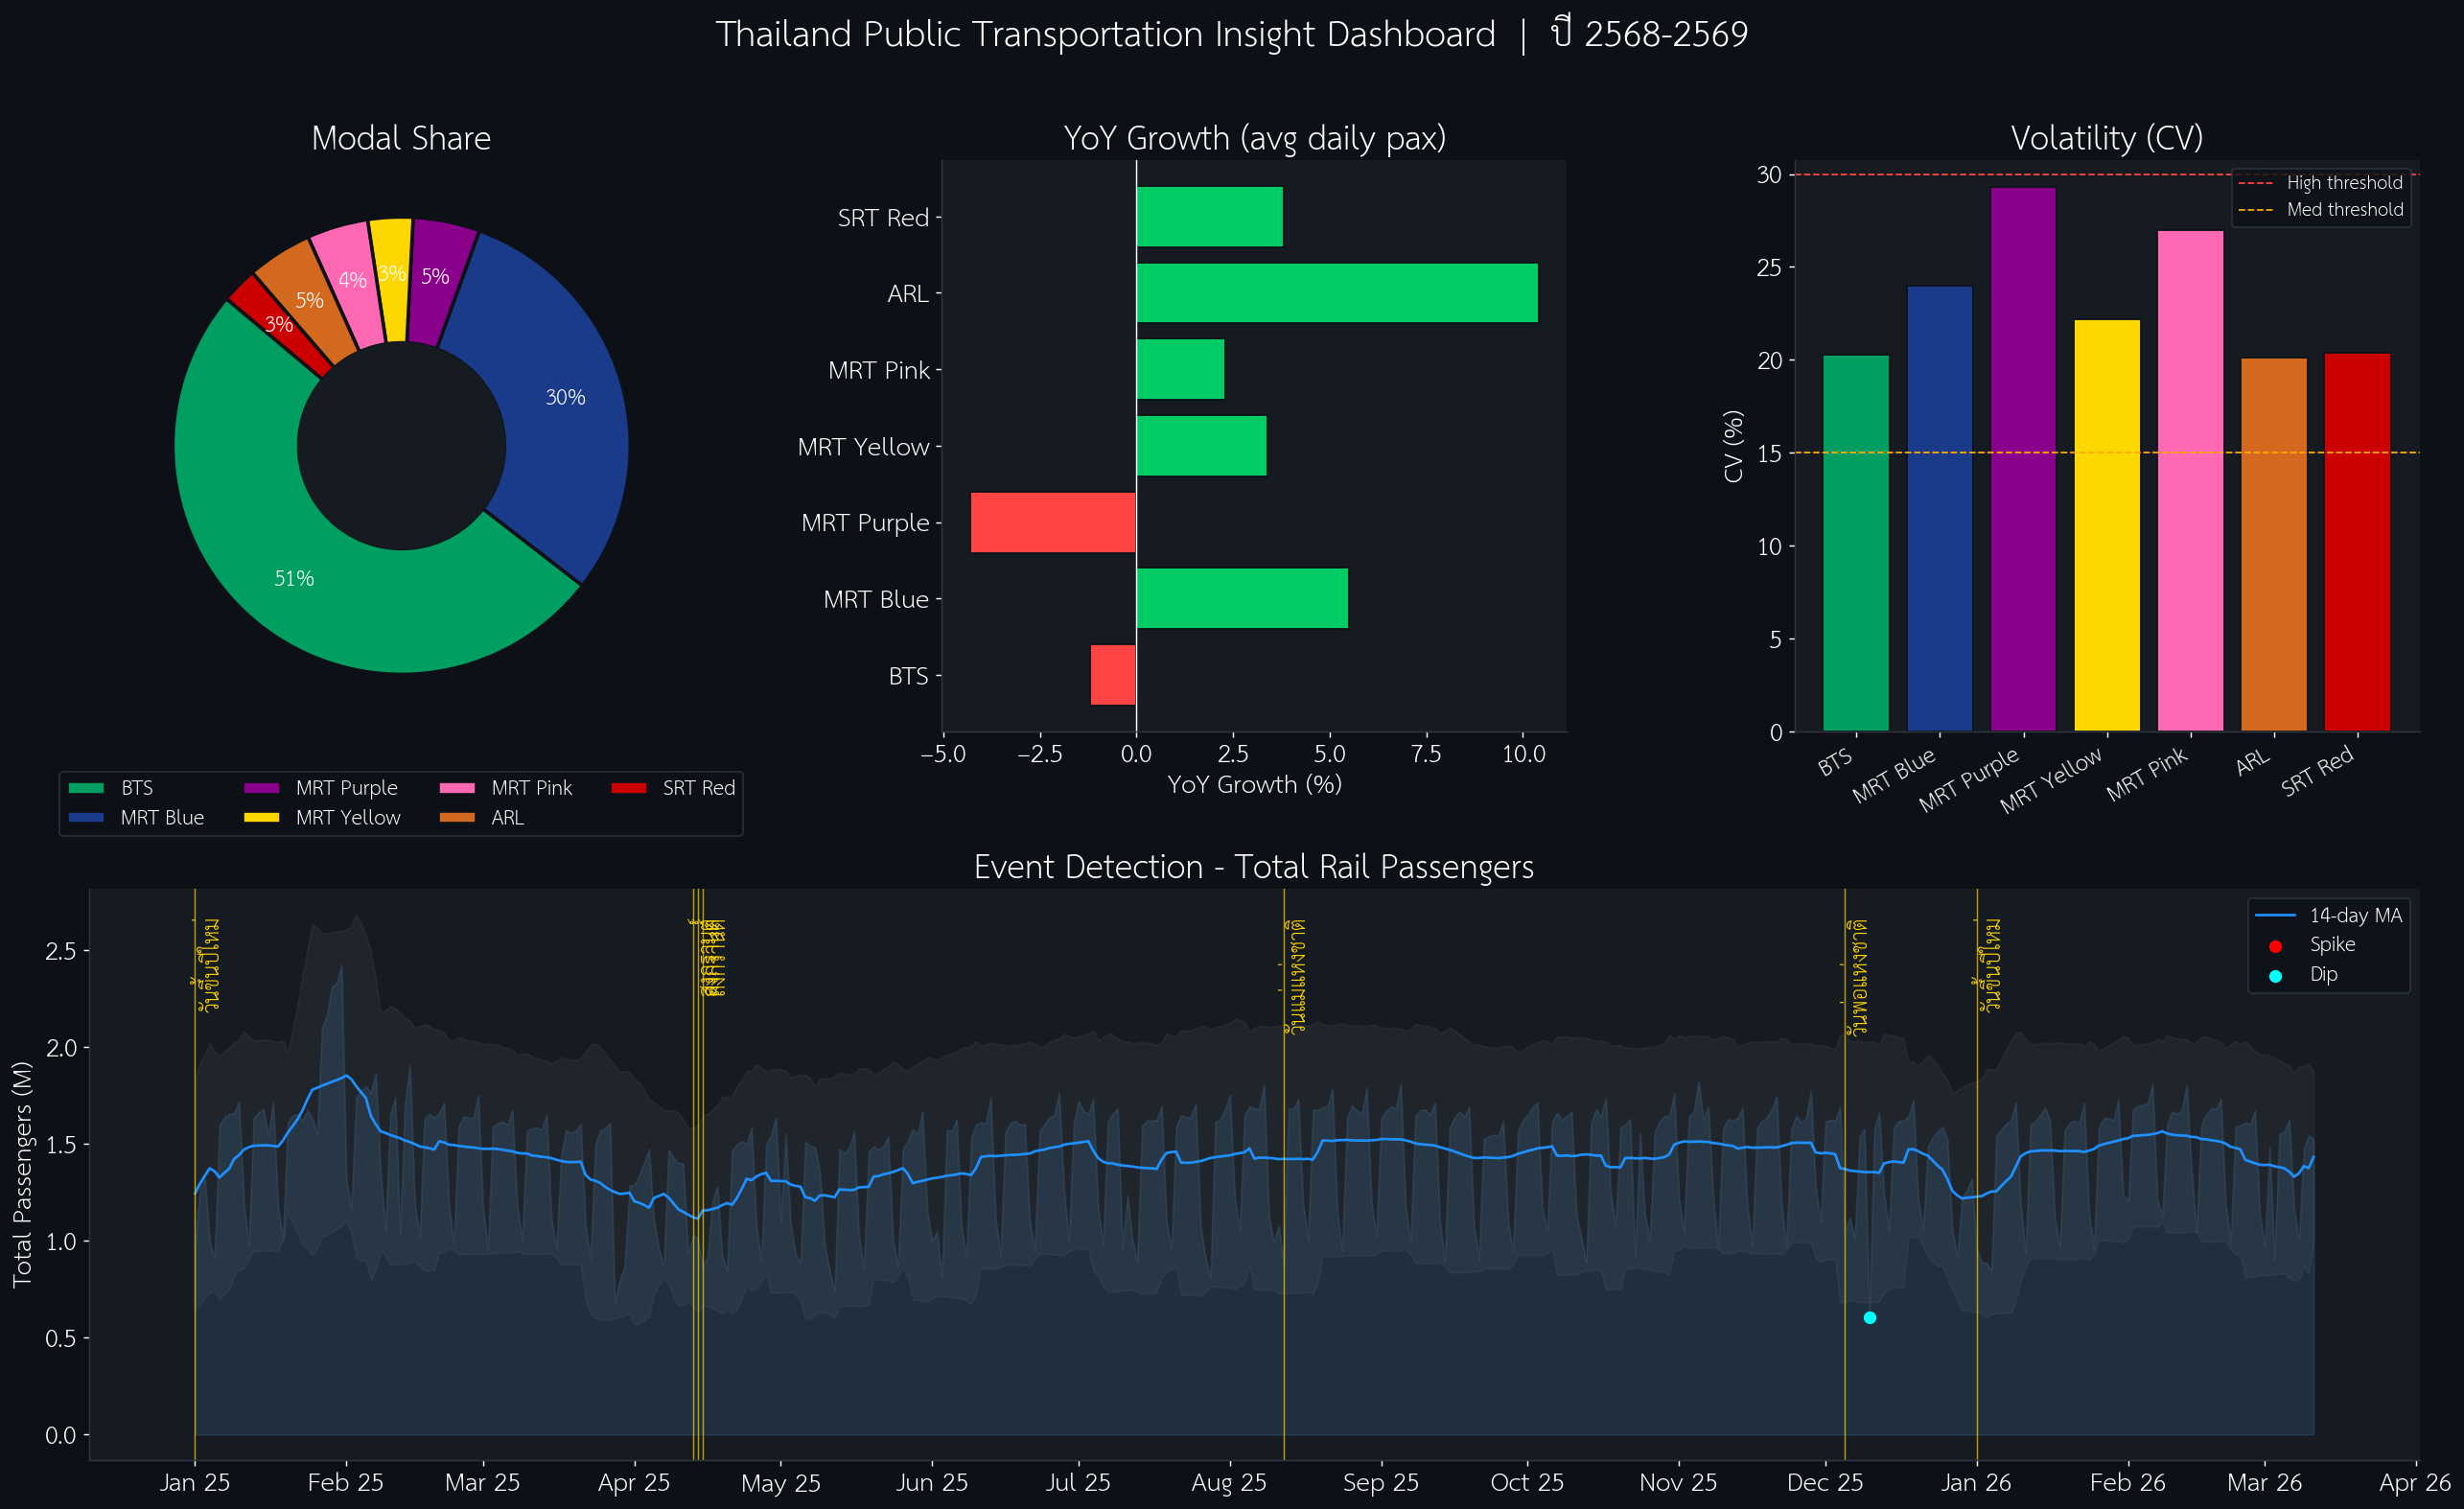

In [50]:
# Combined Insight Dashboard
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor("#0d1117")

# Sub-plots layout
ax1 = fig.add_subplot(2, 3, 1)  # Modal share donut
ax2 = fig.add_subplot(2, 3, 2)  # YoY growth
ax3 = fig.add_subplot(2, 3, 3)  # Volatility CV
ax4 = fig.add_subplot(2, 1, 2)  # Anomaly timeline

dark_style = {"facecolor": "#161b22", "edgecolor": "#30363d"}
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_facecolor("#161b22")
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")

# -- Donut --
wedge_colors = [COLORS[l] for l in LINE_ORDER]
wedges, _, autotexts = ax1.pie(totals[LINE_ORDER], colors=wedge_colors, autopct="%1.0f%%",
    startangle=140, wedgeprops=dict(width=0.55, edgecolor="#0d1117", linewidth=2),
    pctdistance=0.75, textprops={"fontsize": 12, "color": "white"})
for at in autotexts:
    at.set_fontweight("bold")
ax1.add_patch(plt.Circle((0, 0), 0.45, color="#161b22"))
ax1.set_title("Modal Share", color="white", fontweight="bold")
ax1.legend(LINE_ORDER, loc="lower center", fontsize=11, ncol=4,
           labelcolor="white", facecolor="#0d1117", edgecolor="#30363d",
           bbox_to_anchor=(0.5, -0.2))

# -- YoY growth --
g_sorted = growth_pct.reindex(LINE_ORDER)
bar_colors_g = ["#00cc66" if v >= 0 else "#ff4444" for v in g_sorted]
ax2.barh(LINE_ORDER, g_sorted.values, color=bar_colors_g, edgecolor="#0d1117")
ax2.axvline(0, color="white", lw=0.8)
ax2.set_xlabel("YoY Growth (%)", color="white")
ax2.set_title("YoY Growth (avg daily pax)", color="white", fontweight="bold")
ax2.tick_params(colors="white")

# -- CV volatility --
cv_reindexed = cv.reindex(LINE_ORDER)
bar_colors_v = [COLORS[l] for l in LINE_ORDER]
ax3.bar(LINE_ORDER, cv_reindexed.values, color=bar_colors_v, edgecolor="#0d1117")
ax3.axhline(30, color="#ff4444", linestyle="--", lw=1, label="High threshold")
ax3.axhline(15, color="#ffaa00", linestyle="--", lw=1, label="Med threshold")
ax3.set_xticklabels(LINE_ORDER, rotation=30, ha="right", color="white", fontsize=12)
ax3.set_ylabel("CV (%)", color="white")
ax3.set_title("Volatility (CV)", color="white", fontweight="bold")
ax3.legend(fontsize=10, labelcolor="white", facecolor="#0d1117", edgecolor="#30363d")

# -- Anomaly timeline --
ax4.fill_between(daily_total["date"], daily_total["total"] / 1e6, alpha=0.2, color="steelblue")
ax4.plot(daily_total["date"], daily_total["rolling_mean"] / 1e6, color="dodgerblue", lw=1.5, label="14-day MA")
ax4.fill_between(daily_total["date"],
    (daily_total["rolling_mean"] - 2 * daily_total["rolling_std"]) / 1e6,
    (daily_total["rolling_mean"] + 2 * daily_total["rolling_std"]) / 1e6,
    alpha=0.1, color="grey")
ax4.scatter(high["date"], high["total"] / 1e6, color="red", s=40, zorder=5, label="Spike")
ax4.scatter(low["date"],  low["total"]  / 1e6, color="cyan", s=40, zorder=5, label="Dip")

key_events = {k: v for k, v in events.items()
              if v in ["สงกรานต์", "วันขึ้นปีใหม่", "วันแม่แห่งชาติ", "วันพ่อแห่งชาติ"]}
for ts, label in key_events.items():
    row = daily_total[daily_total["date"] == ts]
    if not row.empty:
        ax4.axvline(ts, color="gold", lw=0.8, alpha=0.7)
        ax4.text(ts, ax4.get_ylim()[1] * 0.95 if ax4.get_ylim()[1] > 0 else 2,
                 label, rotation=90, fontsize=12, color="gold", va="top")

ax4.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
ax4.xaxis.set_major_locator(mdates.MonthLocator())
ax4.set_ylabel("Total Passengers (M)", color="white")
ax4.set_title("Event Detection - Total Rail Passengers", color="white", fontweight="bold")
ax4.legend(fontsize=11, labelcolor="white", facecolor="#0d1117", edgecolor="#30363d")

fig.suptitle("Thailand Public Transportation Insight Dashboard  |  ปี 2568-2569",
             fontsize=20, fontweight="bold", color="white", y=1.01)
plt.tight_layout()
plt.show()

# **สรุปเนื้อหาจากฐานข้อมูล (Conclusion)**

เพื่อเป็นการขมวดปมนัยสำคัญและสรุปรวบยอดถึงพฤติกรรมการเดินทางของผู้คนผ่านฐานข้อมูลสถิติผู้โดยสารในระบบขนส่งมวลชนทางรางตลอดระยะเวลาเกือบ 1 ปีครึ่ง เราสามารถประมวลภาพโครงข่ายออกมาได้ดังนี้ครับ:

*   **ความเป็นจุดศูนย์กลางของการเดินทาง:** สายการเดินรถดั้งเดิมอย่าง **รถไฟฟ้า BTS** และ **MRT สีน้ำเงิน** ขีดเส้นใยแมงมุมที่ครอบงำปริมาณการใช้งานในพื้นที่กรุงเทพมหานครและปริมณฑลเป็นหลัก โดยกินพื้นที่ส่วนแบ่งรวมกันมหาศาลกว่า 80% ตัวเลขนี้สะท้อนชัดเจนว่าสายทางเดิมยังคงทำหน้าที่เป็นคลื่นเส้นเลือดใหญ่ในการระบายผู้โดยสารเข้าและออกจากใจกลางกทม. ได้อย่างสัมฤทธิ์ผล
*   **ความสมมาตรแห่งวันทำงาน:** ตัวเลขพฤติกรรมสะท้อนออกมาในทิศทางเดียวกันทั้งหมดว่า โครงข่ายส่วนใหญ่ในไทยมีจุดรวมเป้าหมายที่แท้จริงคือ **"การตอบโจทย์วิถีชีวิตวัยทำงานเป็นที่ตั้ง"** สังเกตได้ความแตกต่างแบบชี้ขาดของตัวเลขระหว่างจำนวนผู้คนบนระบบในวันทำงานที่สูงผิดปกติเมื่อเทียบกับวันหยุดเสาร์-อาทิตย์ โดยสายที่เป็นตัวแทนของเรื่องลักษณะนี้ได้สมบูรณ์แบบที่สุดคือ **MRT สีม่วง** ซึ่งมีผลลัพธ์เป็นโครงข่ายหลักเพื่อป้อนบุคคลพนักงานออฟฟิศปริมณฑลสู่ตัวเมือง
*   **ไฟฝันสู่สังคมใหม่โซนพื้นที่ชานเมือง:** เมื่อเบนเข็มพิจารณาไปที่โครงข่ายน้องใหม่ เราค้นพบการเติบโตในภาพเชิงบวกที่น่าประทับใจเป็นพิเศษของ **รถไฟชานเมืองสายสีแดง** ตัวหนังสือจากสถิติเหล่านี้เป็นสัญญาชีพอันดีว่า ผู้คนบริเวณพื้นที่ด่านรอบนอกกรุงเทพฯ เริ่มปรับขบวนกระบวนทัศน์การสัญจร เลิกพึ่งพาพาหนะส่วนตัวแล้วฝังตัวเข้ามาสู่อ้อมกอดของระบบรางระดับมาตรฐานแล้ว
*   **การเดินทางในช่วงเทศกาล:** และในประเด็นสุดท้าย การทดสอบปัจจัยทางกาลเวลาแสดงให้ประจักษ์ว่า มหกรรมความสุขของประเทศอย่างวันหยุดต่อเนื่อง เทศกาลสงกรานต์ และวันขึ้นปีใหม่ ทิ้งร่องรอยเอาไว้บนกราฟปริมาณผู้โดยสารอย่างแยกขาดไม่ได้ ในจังหวะที่บ้านเมืองสงบเงียบช่วงวันหยุด การใช้งานจะถูกแช่แข็ง แต่ครั้นรุ่งสางของวันเปิดทำงานปฐมฤกษ์ ระบบทั้งปวงจะถูกปลุกระดมให้เปิดรับมวลชนที่ไหลบ่าเข้าสู่โครงสร้างพื้นฐานเหล่านี้อย่างล้นทะลัก (Bounce-Back Spike) อย่างเสมอมาครับ